<a href="https://colab.research.google.com/github/hajyhia/Airbnb_Berlin_Price_predic/blob/main/Airbnb_Berlin_Price_Pedict_EDA2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [114]:
# !pip install missingno
# !pip install geopy
# !pip install matplotlib

In [115]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
# from pandas_profiling import ProfileReport
import numpy as np
import missingno as msno
sns.set()
# plt.style.use('ggplot')
plt.style.use('seaborn-v0_8')
import warnings
import datetime as dt

from sklearn import ensemble, tree, linear_model
from sklearn import tree
from sklearn.metrics import accuracy_score
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.impute import KNNImputer

from scipy.stats import pearsonr
from scipy.stats import ks_2samp
from scipy.stats import norm
from scipy import stats
from scipy.stats import chisquare
from scipy.stats import chi2_contingency
from scipy.stats import f_oneway

# Ignore warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

In [116]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [117]:
df_EDA2 = pd.read_pickle('/content/drive/My Drive/Airbnb/df_EDA2.pkl')

In [163]:
df = df_EDA2.copy()
df = df.drop(columns=['Listing ID'])
df.head()

,Accomodates,Accuracy Rating,Bathrooms,Bedrooms,Beds,Checkin Rating,Cleanliness Rating,Communication Rating,Guests Included,Host Response Rate,Latitude,Location Rating,Longitude,Min Nights,Overall Rating,Price,Reviews,Value Rating,review_date,Host Since,Host Response Time,Is Superhost,neighbourhood,Neighborhood Group,Postal Code,Is Exact Location,Property Type,Room Type,Instant Bookable,Neighbourhood Grouped,Property Type Reduced,Postal Code Reduced,Room Type Encoded,Property Type Reduced Encoded,Neighborhood Group Encoded,Postal Code Reduced Encoded,Host Response Time Encoded
0,2.0,10.0,1.0,1.0,1.0,10.0,10.0,10.0,1.0,50.0,52.54851,9.0,13.40455,2.0,100.0,17.0,7.0,10.0,07-04-18,09-16-08,within a day,False,Prenzlauer Berg,Pankow,10437,True,Apartment,Private room,False,Pankow,Apartment,10,1,0,6,0,1
1,4.0,9.0,1.0,1.0,2.0,9.0,9.0,9.0,2.0,50.0,52.53500,10.0,13.41758,62.0,92.0,90.0,144.0,9.0,06-20-09,10-19-08,within a day,False,Prenzlauer Berg,Pankow,10405,True,Apartment,Entire home/apt,False,Pankow,Apartment,10,0,0,6,0,1
2,2.0,10.0,1.0,1.0,2.0,10.0,10.0,10.0,1.0,100.0,52.54316,10.0,13.41509,2.0,96.0,33.0,229.0,10.0,08-18-09,05-16-09,within an hour,True,Prenzlauer Berg,Pankow,10437,True,Apartment,Private room,False,Pankow,Apartment,10,1,0,6,0,3
3,7.0,10.0,2.5,4.0,7.0,10.0,10.0,10.0,5.0,100.0,52.53303,10.0,13.41605,6.0,100.0,180.0,6.0,10.0,08-09-15,08-25-09,within a day,False,Prenzlauer Berg,Pankow,10405,False,Apartment,Entire home/apt,False,Pankow,Apartment,10,0,0,6,0,1
4,1.0,10.0,1.0,0.0,1.0,9.0,10.0,10.0,1.0,100.0,52.54785,9.0,13.40556,90.0,93.0,70.0,23.0,9.0,06-29-10,11-18-09,within a day,False,Prenzlauer Berg,Pankow,10437,True,Apartment,Entire home/apt,False,Pankow,Apartment,10,0,0,6,0,1


In [164]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23460 entries, 0 to 23535
Data columns (total 37 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Accomodates                    23460 non-null  float64
 1   Accuracy Rating                18862 non-null  float64
 2   Bathrooms                      23431 non-null  float64
 3   Bedrooms                       23440 non-null  float64
 4   Beds                           23426 non-null  float64
 5   Checkin Rating                 18844 non-null  float64
 6   Cleanliness Rating             18866 non-null  float64
 7   Communication Rating           18860 non-null  float64
 8   Guests Included                23460 non-null  float64
 9   Host Response Rate             12984 non-null  float64
 10  Latitude                       23460 non-null  float64
 11  Location Rating                18845 non-null  float64
 12  Longitude                      23460 non-null  floa

## Declare data columns Lists

In [120]:
numerical_columns = ['Accomodates', 'Bathrooms', 'Bedrooms', 'Beds', 'Guests Included','Min Nights','Reviews','Price']
rating_columns = ['Value Rating','Location Rating', 'Cleanliness Rating','Checkin Rating','Accuracy Rating','Communication Rating','Host Response Rate','Overall Rating']
boolean_columns = ['Is Superhost','Is Exact Location', 'Instant Bookable']
categorical_columns = ['Room Type','Property Type Reduced','Neighborhood Group','Postal Code Reduced','Host Response Time'] # , 'Neighbourhood Grouped'
categorical_encoded_columns = ['Room Type Encoded','Property Type Reduced Encoded','Neighborhood Group Encoded','Postal Code Reduced Encoded','Host Response Time Encoded']
date_columns = ['review_date','Host Since']
geo_columns = ['Latitude','Longitude']
num_non_dummy_columns = numerical_columns + rating_columns + categorical_encoded_columns + geo_columns

In [121]:
df_num = df._get_numeric_data().dropna()
df_num.shape

(11503, 27)

## Outliers

The box extends from the first quartile (Q1) to the third quartile (Q3) of the data, with a line at the median. The whiskers extend from the box to the farthest data point lying within 1.5x the inter-quartile range (IQR) from the box. Flier points are those past the end of the whiskers. See

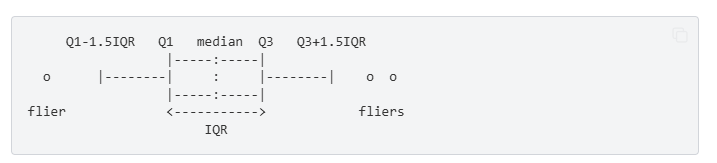

In [122]:
df_num_non_dummy = df_num.drop(columns=boolean_columns)
num_non_dummy_columns = df_num_non_dummy.columns
df_num_non_dummy.shape

(11503, 24)

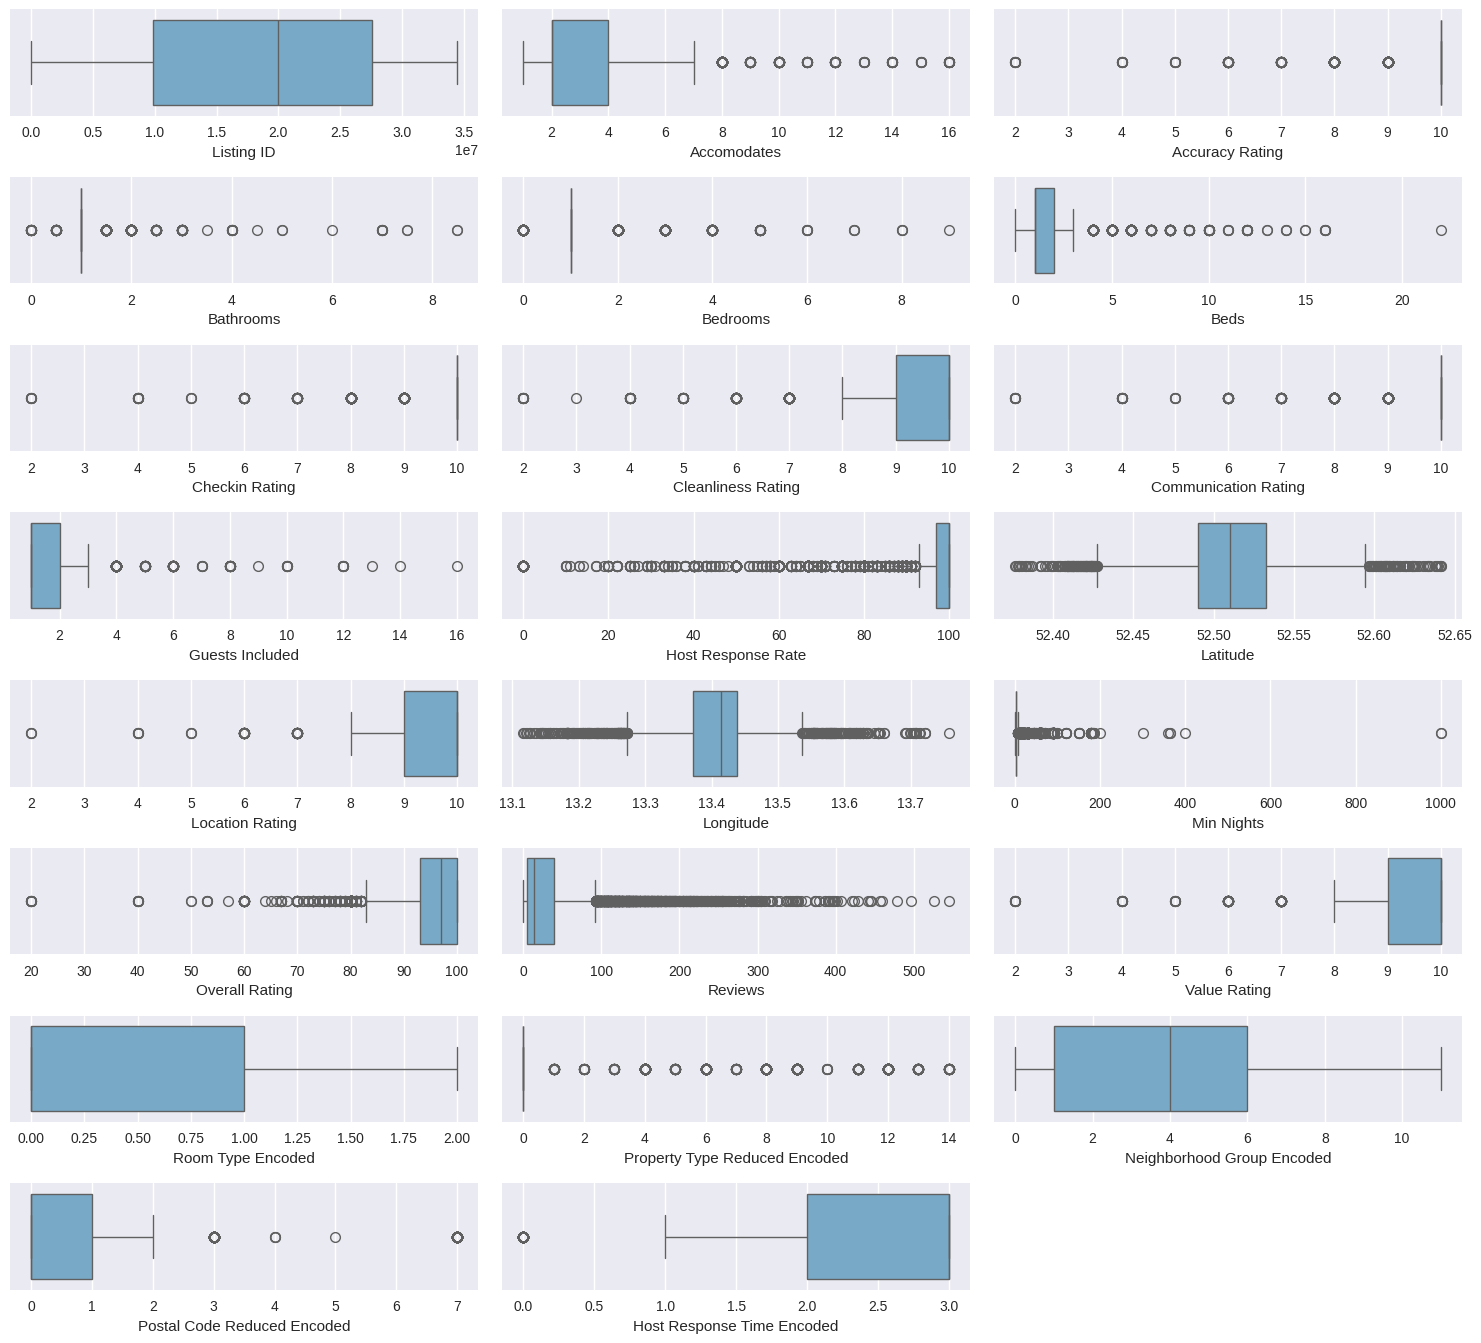

In [123]:
def outlier_boxplot(df):
  plt.figure(figsize=(15, 40))
  j = 1
  r = len(df.columns)
  for i, col in enumerate([c for c in df if c != 'Price'], 1):
    plt.subplot(r, 3, i)
    sns.boxplot(x=df[col].dropna(), palette='Blues')
    plt.subplots_adjust(hspace = 0.6)

  plt.tight_layout()
  plt.show()

outlier_boxplot(df_num_non_dummy)

In [124]:
# def outlier_boxplot(df):
#   plt.figure(figsize=(15, 50))
#   j = 1
#   r = len(df.columns)
#   for i, col in enumerate([c for c in df if c != 'Price'], 1):
#     plt.subplot(r, 2, j)
#     sns.distplot(df[col].dropna())
#     plt.title(f'Distribution of {col}')
#     plt.subplots_adjust(hspace = 0.6)

#     plt.subplot(r, 2, j + 1)
#     sns.boxplot(x=df[col].dropna(), palette='Blues')
#     plt.subplots_adjust(hspace = 0.6)
#     j = j + 2

#   plt.tight_layout()
#   plt.show()

# outlier_boxplot(df_num_non_dummy)

The boxplots reveal potential outliers in several numerical features, particularly:

1. Price: Ignored as it is the target value
2. Reviews: Some listings have significantly higher review counts than others.
3. Bedrooms, Bathrooms, Beds, Accommodates: Some properties might have unrealistic values (e.g., too many or too few bedrooms relative to accommodations).

In [125]:
def df_describe(df, numerical_columns):
  min_vals = []
  max_vals = []
  Q1_ = []
  Q2_ = []
  Q3_ = []
  IQR_ = []
  lower_bound_ = []
  upper_bound_ = []
  for column in df_num_non_dummy:
    Q1 = df[column].quantile(0.25)
    Q2 = df[column].quantile(0.50)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    min_vals.append(df[column].min())
    max_vals.append(df[column].max())
    Q1_.append(Q1)
    Q2_.append(Q2)
    Q3_.append(Q3)
    IQR_.append(IQR)
    lower_bound_.append(lower_bound)
    upper_bound_.append(upper_bound)

  # return pd.DataFrame(data = [min_vals, lower_bound_,Q1_,Q2_,Q3_ ,IQR_,upper_bound_,max_vals],
  #            columns=["min_vals", "lower_bound","Q1","Q2","Q3","IQR","upper_bound","max_vals"])
  return pd.DataFrame({
      'min': min_vals,
      'Q1(25%)': Q1_,
      'Q2(50%)': Q2_,
      'Q3(75%)': Q3_,
      'max': max_vals,
      'IQR': IQR_,
      'lower_bound': lower_bound_,
      'upper_bound': upper_bound_}, index=num_non_dummy_columns)

df_describe(df_num_non_dummy, num_non_dummy_columns)

,min,Q1(25%),Q2(50%),Q3(75%),max,IQR,lower_bound,upper_bound
Listing ID,2695.00000,9.860174e+06,1.998948e+07,2.759264e+07,3.446541e+07,1.773246e+07,-1.673852e+07,5.419133e+07
Accomodates,1.00000,2.000000e+00,2.000000e+00,4.000000e+00,1.600000e+01,2.000000e+00,-1.000000e+00,7.000000e+00
Accuracy Rating,2.00000,1.000000e+01,1.000000e+01,1.000000e+01,1.000000e+01,0.000000e+00,1.000000e+01,1.000000e+01
Bathrooms,0.00000,1.000000e+00,1.000000e+00,1.000000e+00,8.500000e+00,0.000000e+00,1.000000e+00,1.000000e+00
Bedrooms,0.00000,1.000000e+00,1.000000e+00,1.000000e+00,9.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00
Beds,0.00000,1.000000e+00,1.000000e+00,2.000000e+00,2.200000e+01,1.000000e+00,-5.000000e-01,3.500000e+00
Checkin Rating,2.00000,1.000000e+01,1.000000e+01,1.000000e+01,1.000000e+01,0.000000e+00,1.000000e+01,1.000000e+01
Cleanliness Rating,2.00000,9.000000e+00,1.000000e+01,1.000000e+01,1.000000e+01,1.000000e+00,7.500000e+00,1.150000e+01
Communication Rating,2.00000,1.000000e+01,1.000000e+01,1.000000e+01,1.000000e+01,0.000000e+00,1.000000e+01,1.000000e+01
Guests Included,1.00000,1.000000e+00,1.000000e+00,2.000000e+00,1.600000e+01,1.000000e+00,-5.000000e-01,3.500000e+00


## Data Cleansing

### outliers_df

Based on previous histograms and skewness visualizations, we can observe that the data is not normally distributed. To identify outliers, we will apply the IQR method, establishing boundaries before Q1 and after Q3. Any values falling outside these boundaries will be considered outliers.

In [126]:
def count_outliers_df(df):
    total_outliers = pd.DataFrame(columns=['Outlier count', 'Percent'])
    # for col in df:  # Ensure processing numeric columns only
    for col in [c for c in df if c != 'Price']:  # Ensure processing numeric columns only and exclude Price
        temp = pd.DataFrame(df[col])
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_limit = Q1 - 1.5 * IQR
        upper_limit = Q3 + 1.5 * IQR
        # Filter rows that are outliers in either direction
        temp_outliers = temp[(temp[col] > upper_limit) | (temp[col] < lower_limit)]
        num_outliers = len(temp_outliers)
        total_outliers.loc[col] = [num_outliers, num_outliers / len(df) * 100]

    return total_outliers[total_outliers['Percent'] > 0]

**Consider replacing outliers_df dataframe with only outliers_df_columns**

In [127]:
len(df_num_non_dummy.columns)

24

In [128]:
# Assume df_num_non_dummy is your DataFrame
# Call the function and sort results
outliers_df = count_outliers_df(df_num_non_dummy).sort_values('Percent', ascending=False)
outliers_df, outliers_df.shape

(                               Outlier count    Percent
 Bedrooms                              3085.0  26.819091
 Accuracy Rating                       2624.0  22.811440
 Host Response Rate                    2609.0  22.681040
 Checkin Rating                        2181.0  18.960271
 Communication Rating                  2004.0  17.421542
 Property Type Reduced Encoded         1604.0  13.944188
 Bathrooms                             1468.0  12.761888
 Reviews                               1165.0  10.127793
 Beds                                  1119.0   9.727897
 Min Nights                            1017.0   8.841172
 Guests Included                        611.0   5.311658
 Postal Code Reduced Encoded            586.0   5.094323
 Overall Rating                         538.0   4.677041
 Host Response Time Encoded             416.0   3.616448
 Longitude                              415.0   3.607754
 Cleanliness Rating                     345.0   2.999218
 Accomodates                   

In [129]:
outliers_df.to_csv('/content/drive/My Drive/Airbnb/outliers_df.csv')

### new_df_outliers - labeling with 'Outlier'
Labeling every outlier with 'Outlier'

In [130]:
outliers_df.index

Index(['Bedrooms', 'Accuracy Rating', 'Host Response Rate', 'Checkin Rating',
       'Communication Rating', 'Property Type Reduced Encoded', 'Bathrooms',
       'Reviews', 'Beds', 'Min Nights', 'Guests Included',
       'Postal Code Reduced Encoded', 'Overall Rating',
       'Host Response Time Encoded', 'Longitude', 'Cleanliness Rating',
       'Accomodates', 'Latitude', 'Value Rating', 'Location Rating'],
      dtype='object')

In [131]:
def outliers(df):
    label_out_df = df.copy()
    for col in label_out_df:
        if col in outliers_df.index:
            Q1 = label_out_df[col].quantile(0.25)
            Q3 = label_out_df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_limit = Q1 - 1.5 * IQR
            upper_limit = Q3 + 1.5 * IQR
            label_out_df[col] = np.where(label_out_df[col] > upper_limit, 'Outlier',
                                         np.where(label_out_df[col] < lower_limit,
                                                  'Outlier', label_out_df[col]))
    return label_out_df

new_df_outliers = outliers(df)
new_df_outliers.head(5)

,Listing ID,Accomodates,Accuracy Rating,Bathrooms,Bedrooms,Beds,Checkin Rating,Cleanliness Rating,Communication Rating,Guests Included,Host Response Rate,Latitude,Location Rating,Longitude,Min Nights,Overall Rating,Price,Reviews,Value Rating,review_date,Host Since,Host Response Time,Is Superhost,neighbourhood,Neighborhood Group,Postal Code,Is Exact Location,Property Type,Room Type,Instant Bookable,Neighbourhood Grouped,Property Type Reduced,Postal Code Reduced,Room Type Encoded,Property Type Reduced Encoded,Neighborhood Group Encoded,Postal Code Reduced Encoded,Host Response Time Encoded
0,2695,2.0,10.0,1.0,1.0,1.0,10.0,10.0,10.0,1.0,Outlier,52.54851,9.0,13.40455,2.0,100.0,17.0,7.0,10.0,07-04-18,09-16-08,within a day,False,Prenzlauer Berg,Pankow,10437,True,Apartment,Private room,False,Pankow,Apartment,10,1,0,6,0,1
1,3176,4.0,Outlier,1.0,1.0,2.0,Outlier,9.0,Outlier,Outlier,Outlier,52.535,10.0,13.41758,Outlier,92.0,90.0,Outlier,9.0,06-20-09,10-19-08,within a day,False,Prenzlauer Berg,Pankow,10405,True,Apartment,Entire home/apt,False,Pankow,Apartment,10,0,0,6,0,1
2,7071,2.0,10.0,1.0,1.0,2.0,10.0,10.0,10.0,1.0,100.0,52.54316,10.0,13.41509,2.0,96.0,33.0,Outlier,10.0,08-18-09,05-16-09,within an hour,True,Prenzlauer Berg,Pankow,10437,True,Apartment,Private room,False,Pankow,Apartment,10,1,0,6,0,3
3,9991,Outlier,10.0,Outlier,Outlier,Outlier,10.0,10.0,10.0,Outlier,100.0,52.53303,10.0,13.41605,6.0,100.0,180.0,6.0,10.0,08-09-15,08-25-09,within a day,False,Prenzlauer Berg,Pankow,10405,False,Apartment,Entire home/apt,False,Pankow,Apartment,10,0,0,6,0,1
4,14325,1.0,10.0,1.0,Outlier,1.0,Outlier,10.0,10.0,1.0,100.0,52.54785,9.0,13.40556,Outlier,93.0,70.0,23.0,9.0,06-29-10,11-18-09,within a day,False,Prenzlauer Berg,Pankow,10437,True,Apartment,Entire home/apt,False,Pankow,Apartment,10,0,0,6,0,1


### df_outliers - 0/1

Creating a dataframe with outliers as 1 and non-outliers as 0:

In [132]:
df_outliers = new_df_outliers.isin(['Outlier'])
df_outliers = df_outliers.astype('int')
df_outliers

,Listing ID,Accomodates,Accuracy Rating,Bathrooms,Bedrooms,Beds,Checkin Rating,Cleanliness Rating,Communication Rating,Guests Included,Host Response Rate,Latitude,Location Rating,Longitude,Min Nights,Overall Rating,Price,Reviews,Value Rating,review_date,Host Since,Host Response Time,Is Superhost,neighbourhood,Neighborhood Group,Postal Code,Is Exact Location,Property Type,Room Type,Instant Bookable,Neighbourhood Grouped,Property Type Reduced,Postal Code Reduced,Room Type Encoded,Property Type Reduced Encoded,Neighborhood Group Encoded,Postal Code Reduced Encoded,Host Response Time Encoded
0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,1,0,0,0,1,0,1,1,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,1,0,1,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23531,0,0,0,0,0,0,0,0,0,0,1,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
23532,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
23533,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
23534,0,1,0,0,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


Now that we have a dataframe saving all the outliers we'll convert all the outliers to nulls, just so I can see differences in distribution with and without outliers and then decide which of the outliers to remove or not:

In [133]:
def capping(df):
    temp = df.copy()
    for col in temp:
        if col in outliers_df.index:
            Q1 = temp[col].quantile(0.25)
            Q3 = temp[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_limit = Q1 - 1.5 * IQR
            upper_limit = Q3 + 1.5 * IQR
            temp[col] = np.where(temp[col] > upper_limit,np.nan,np.where(temp[col] < lower_limit,np.nan,temp[col]))
    return temp
temp = capping(df)
temp

,Listing ID,Accomodates,Accuracy Rating,Bathrooms,Bedrooms,Beds,Checkin Rating,Cleanliness Rating,Communication Rating,Guests Included,Host Response Rate,Latitude,Location Rating,Longitude,Min Nights,Overall Rating,Price,Reviews,Value Rating,review_date,Host Since,Host Response Time,Is Superhost,neighbourhood,Neighborhood Group,Postal Code,Is Exact Location,Property Type,Room Type,Instant Bookable,Neighbourhood Grouped,Property Type Reduced,Postal Code Reduced,Room Type Encoded,Property Type Reduced Encoded,Neighborhood Group Encoded,Postal Code Reduced Encoded,Host Response Time Encoded
0,2695,2.0,10.0,1.0,1.0,1.0,10.0,10.0,10.0,1.0,NaN,52.54851,9.0,13.40455,2.0,100.0,17.0,7.0,10.0,07-04-18,09-16-08,within a day,False,Prenzlauer Berg,Pankow,10437,True,Apartment,Private room,False,Pankow,Apartment,10,1,0.0,6,0.0,1.0
1,3176,4.0,NaN,1.0,1.0,2.0,NaN,9.0,NaN,NaN,NaN,52.53500,10.0,13.41758,NaN,92.0,90.0,NaN,9.0,06-20-09,10-19-08,within a day,False,Prenzlauer Berg,Pankow,10405,True,Apartment,Entire home/apt,False,Pankow,Apartment,10,0,0.0,6,0.0,1.0
2,7071,2.0,10.0,1.0,1.0,2.0,10.0,10.0,10.0,1.0,100.0,52.54316,10.0,13.41509,2.0,96.0,33.0,NaN,10.0,08-18-09,05-16-09,within an hour,True,Prenzlauer Berg,Pankow,10437,True,Apartment,Private room,False,Pankow,Apartment,10,1,0.0,6,0.0,3.0
3,9991,NaN,10.0,NaN,NaN,NaN,10.0,10.0,10.0,NaN,100.0,52.53303,10.0,13.41605,6.0,100.0,180.0,6.0,10.0,08-09-15,08-25-09,within a day,False,Prenzlauer Berg,Pankow,10405,False,Apartment,Entire home/apt,False,Pankow,Apartment,10,0,0.0,6,0.0,1.0
4,14325,1.0,10.0,1.0,NaN,1.0,NaN,10.0,10.0,1.0,100.0,52.54785,9.0,13.40556,NaN,93.0,70.0,23.0,9.0,06-29-10,11-18-09,within a day,False,Prenzlauer Berg,Pankow,10437,True,Apartment,Entire home/apt,False,Pankow,Apartment,10,0,0.0,6,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23531,34678365,3.0,NaN,1.0,1.0,2.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,48.0,0.0,NaN,None,10-23-18,within a few hours,False,Wannsee,Steglitz - Zehlendorf,14109,False,Apartment,Entire home/apt,True,Steglitz - Zehlendorf,Apartment,14,0,0.0,9,NaN,2.0
23532,34681094,2.0,NaN,1.0,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.49340,5.0,NaN,30.0,0.0,NaN,None,05-13-19,None,False,Mitte,Pankow,13125,True,Apartment,Private room,True,Mitte,Apartment,13,1,0.0,6,2.0,4.0
23533,34681403,1.0,NaN,NaN,1.0,1.0,NaN,NaN,NaN,1.0,NaN,52.45402,NaN,13.43864,2.0,NaN,17.0,0.0,NaN,None,07-31-14,None,False,Britz,NeukÃ¶lln,12347,True,Apartment,Private room,True,NeukÃ¶lln,Apartment,12,1,0.0,5,1.0,4.0
23534,34681413,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,52.47342,NaN,NaN,2.0,NaN,52.0,0.0,NaN,None,05-13-19,None,False,KÃ¶penick,Treptow - KÃ¶penick,12555,True,Apartment,Entire home/apt,True,Treptow - KÃ¶penick,Apartment,12,0,0.0,11,1.0,4.0


In [134]:
temp.to_csv('/content/drive/My Drive/Airbnb/outliers_q_df.csv')

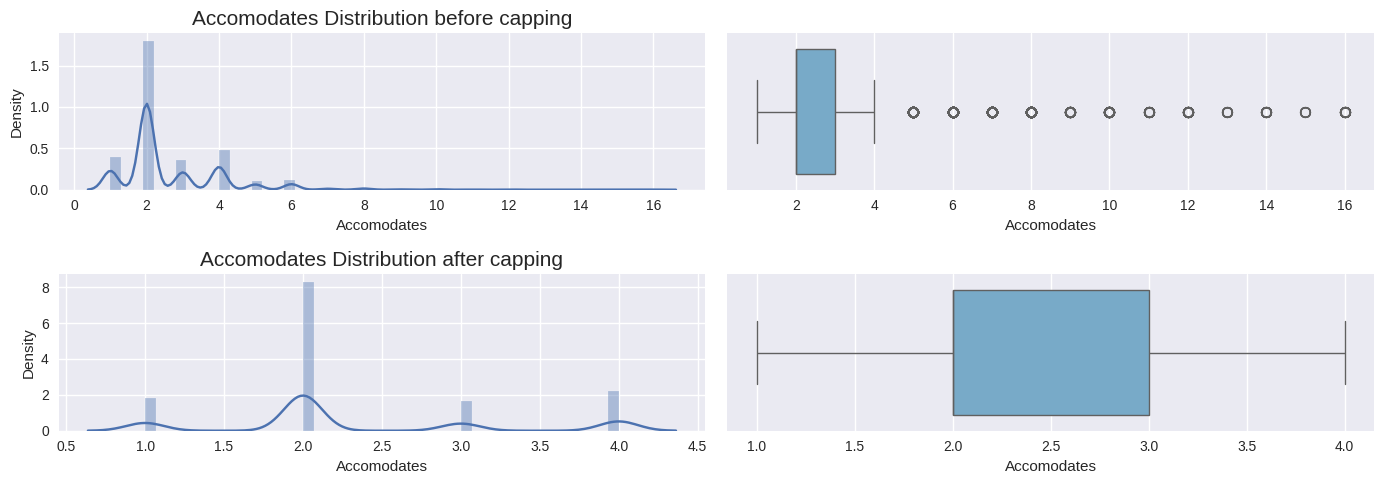

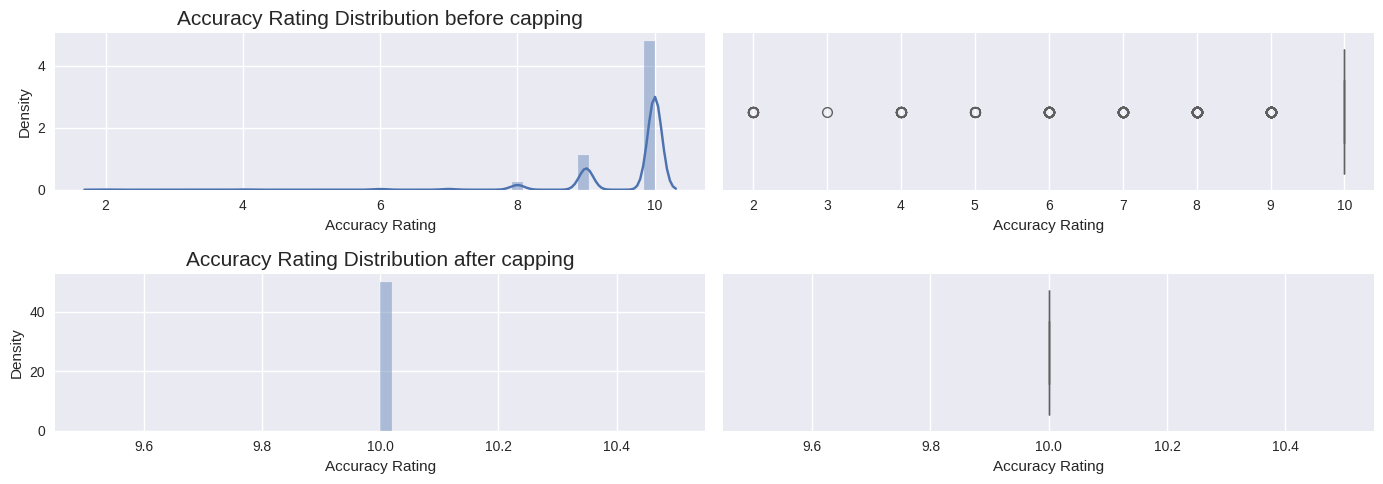

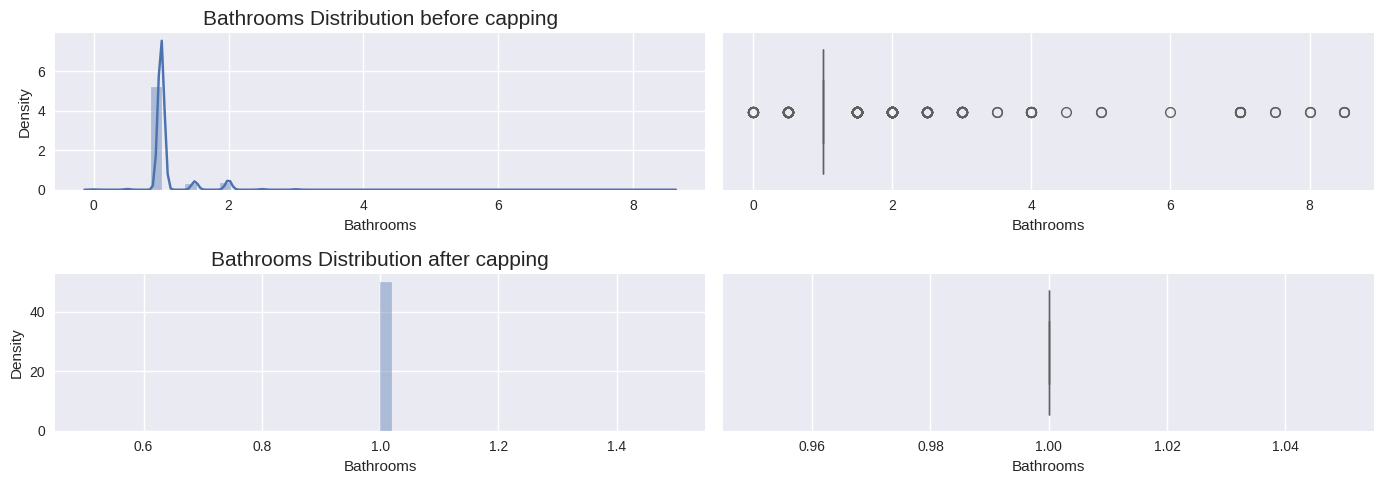

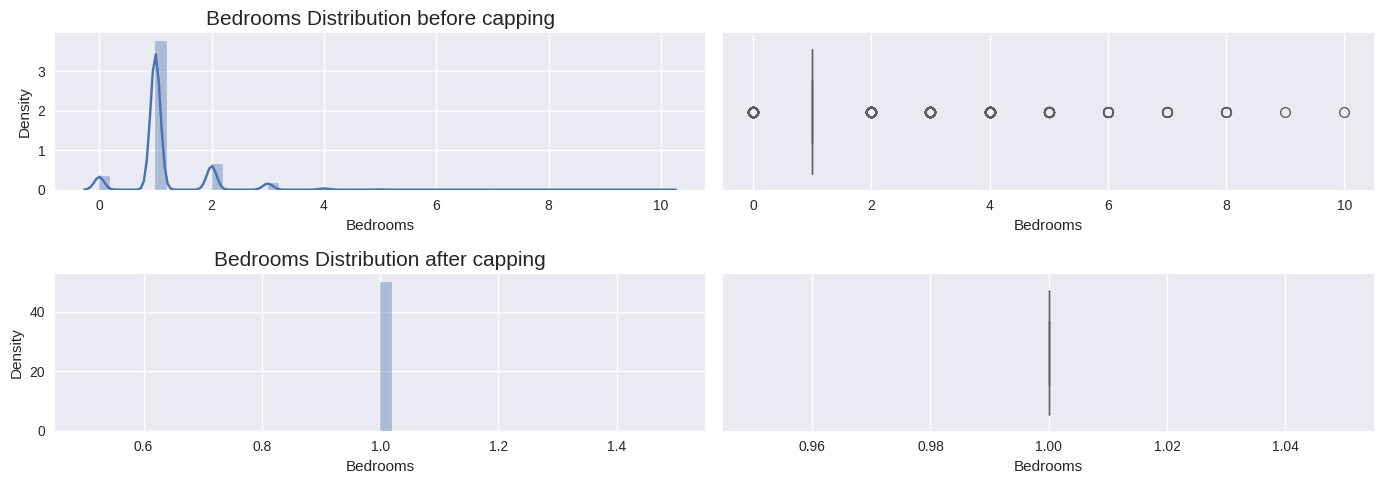

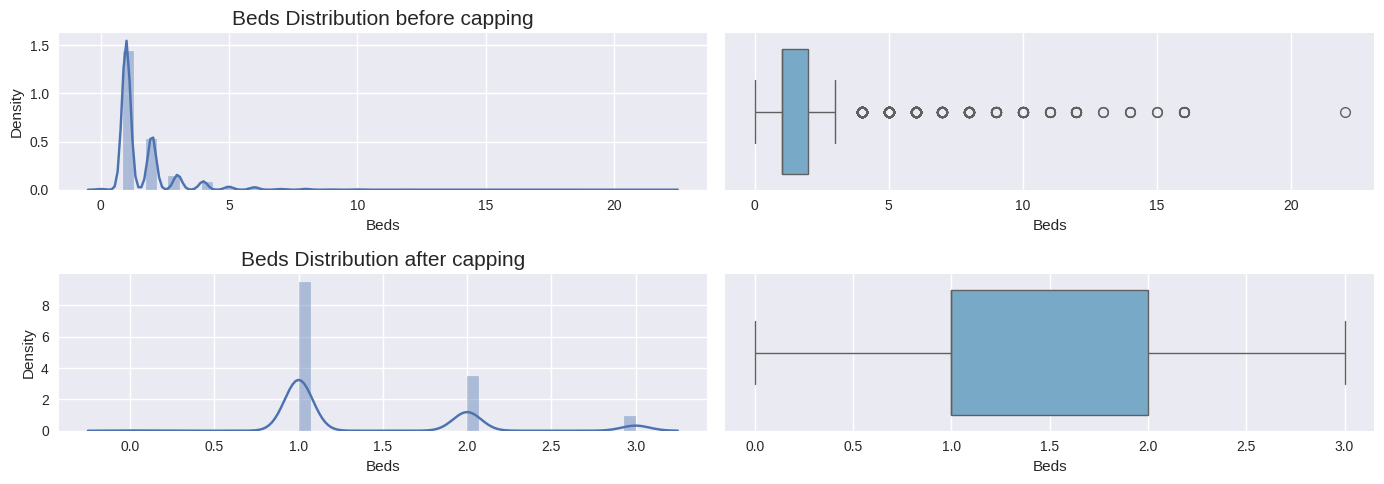

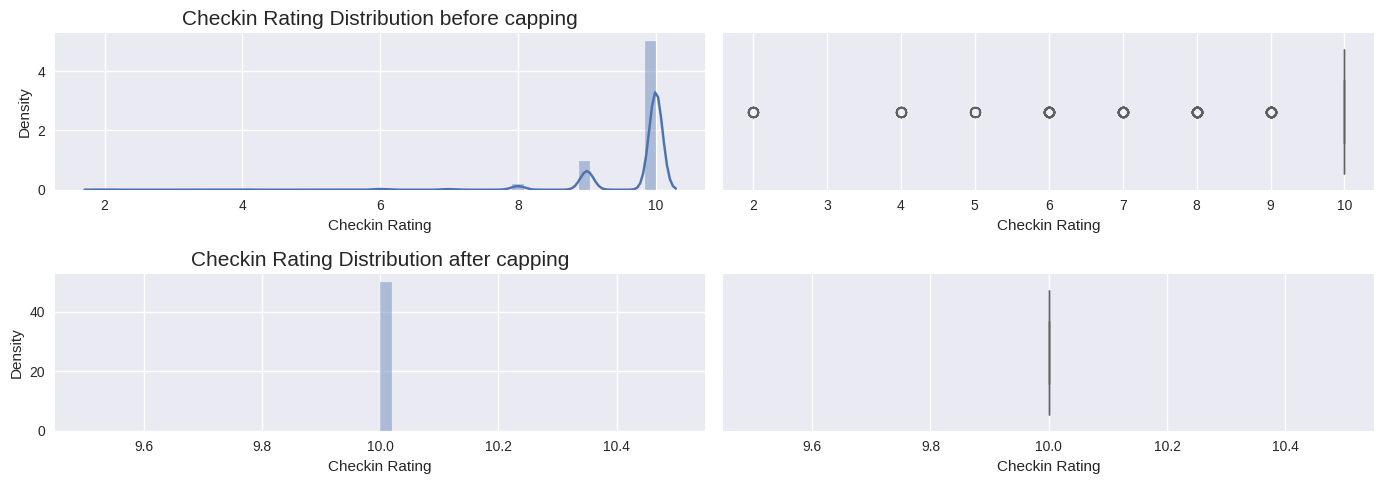

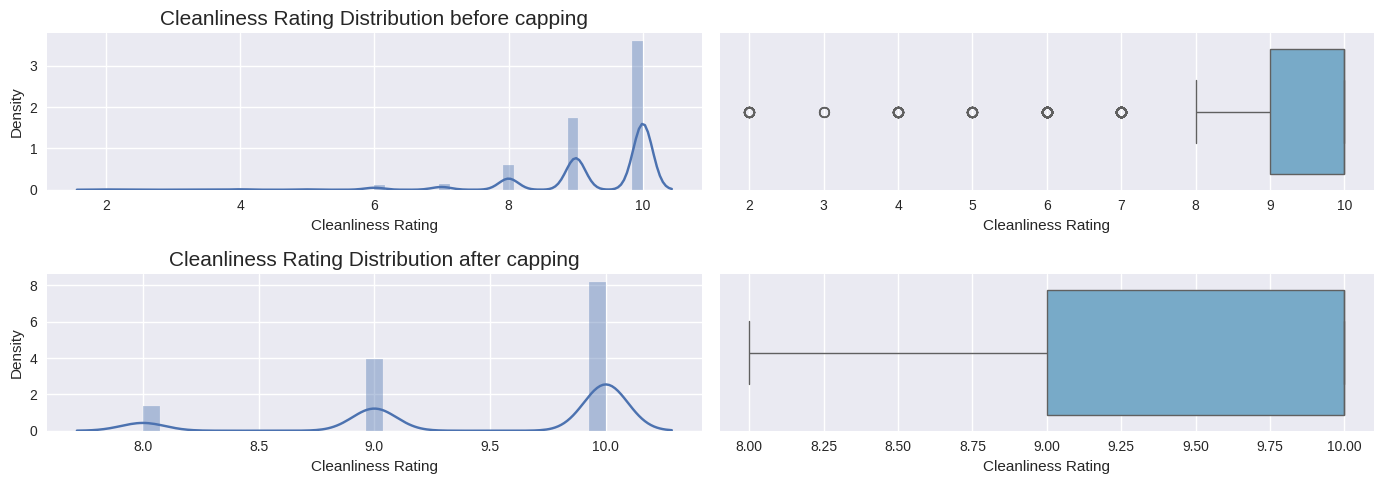

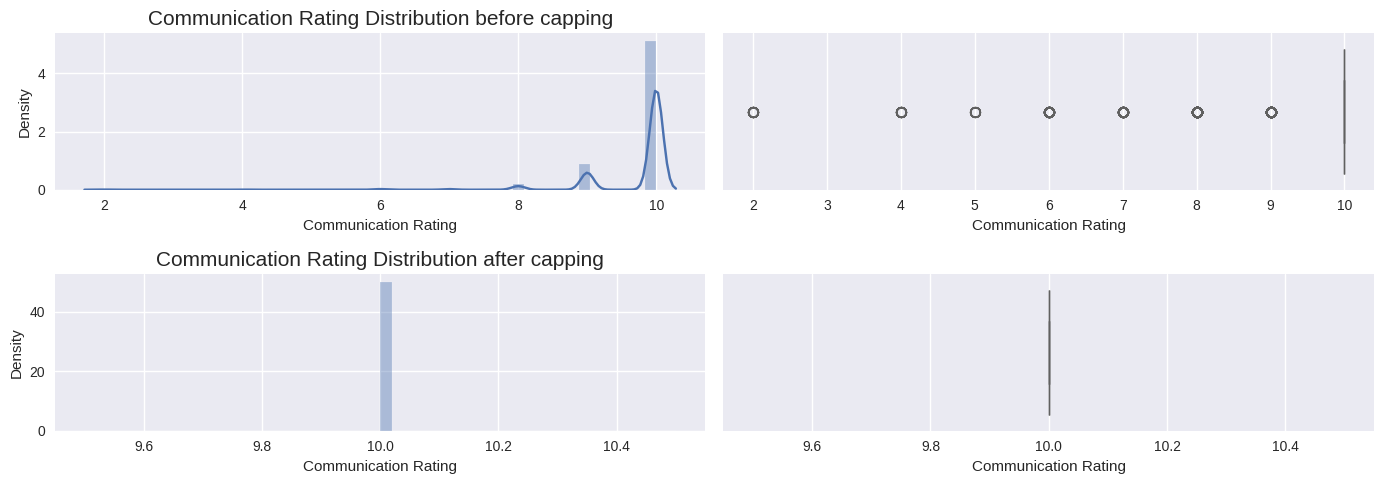

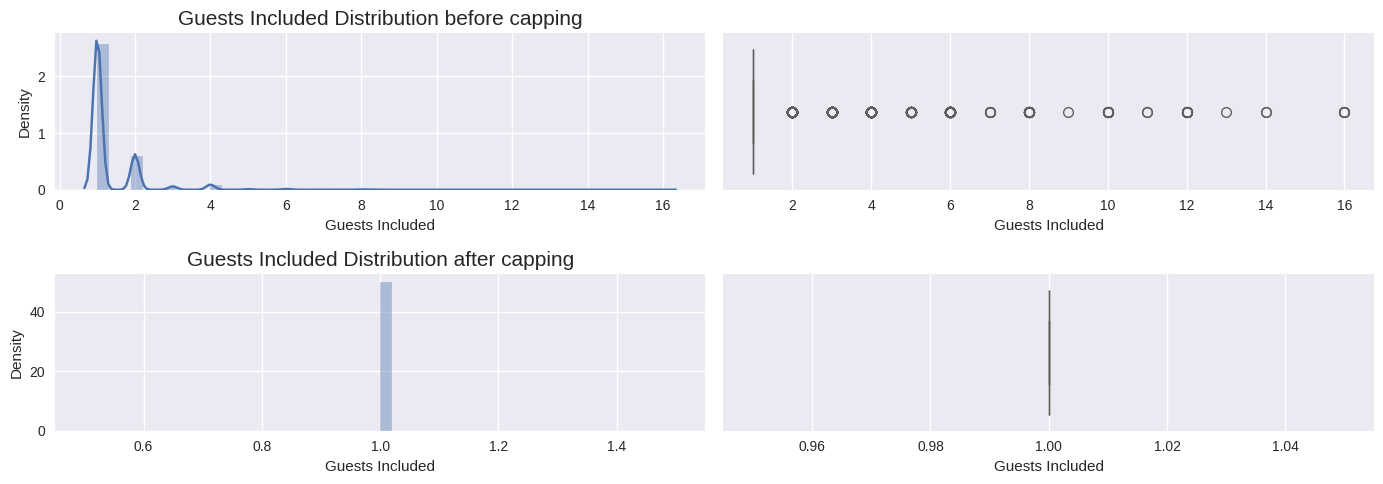

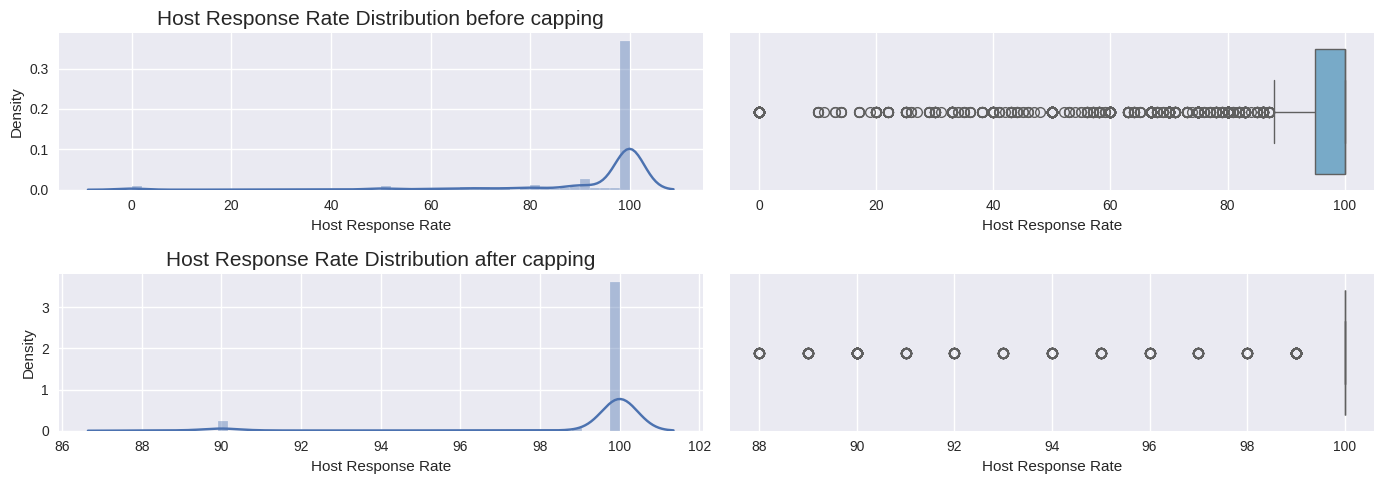

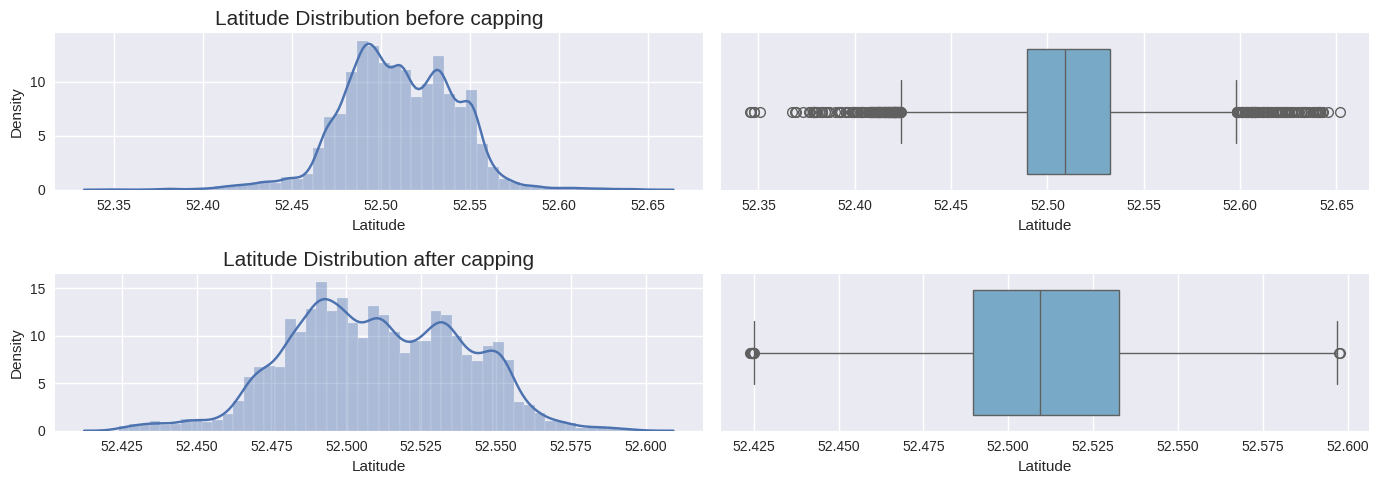

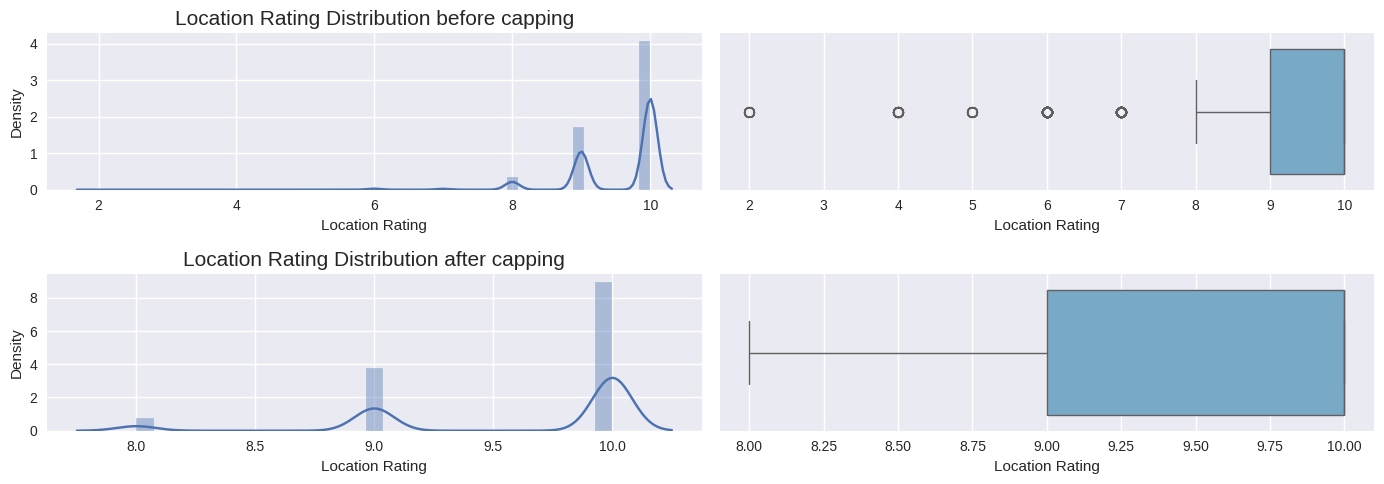

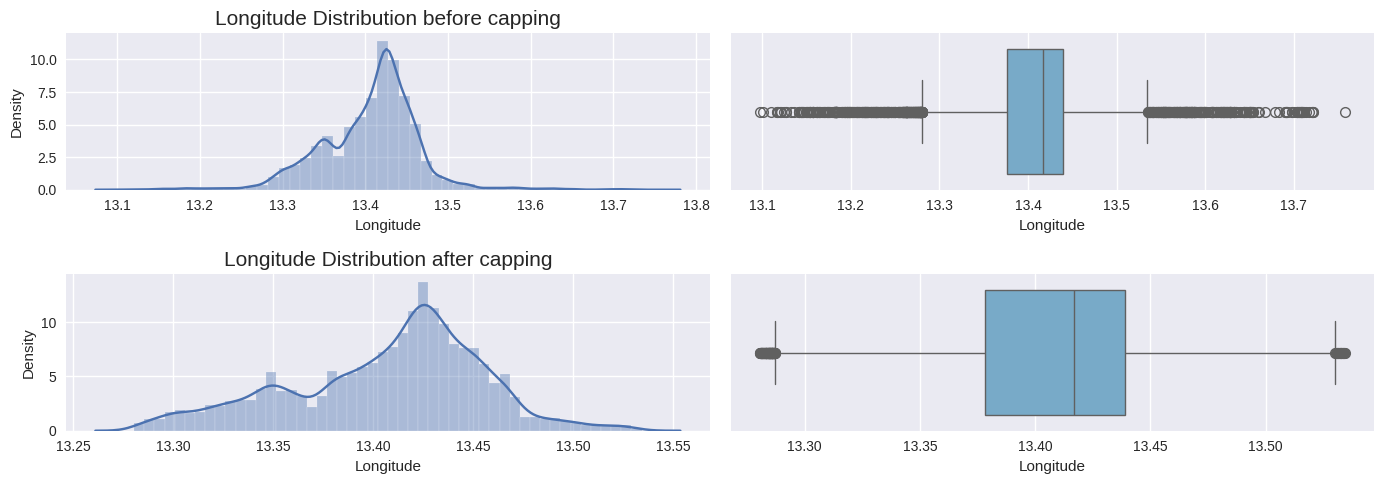

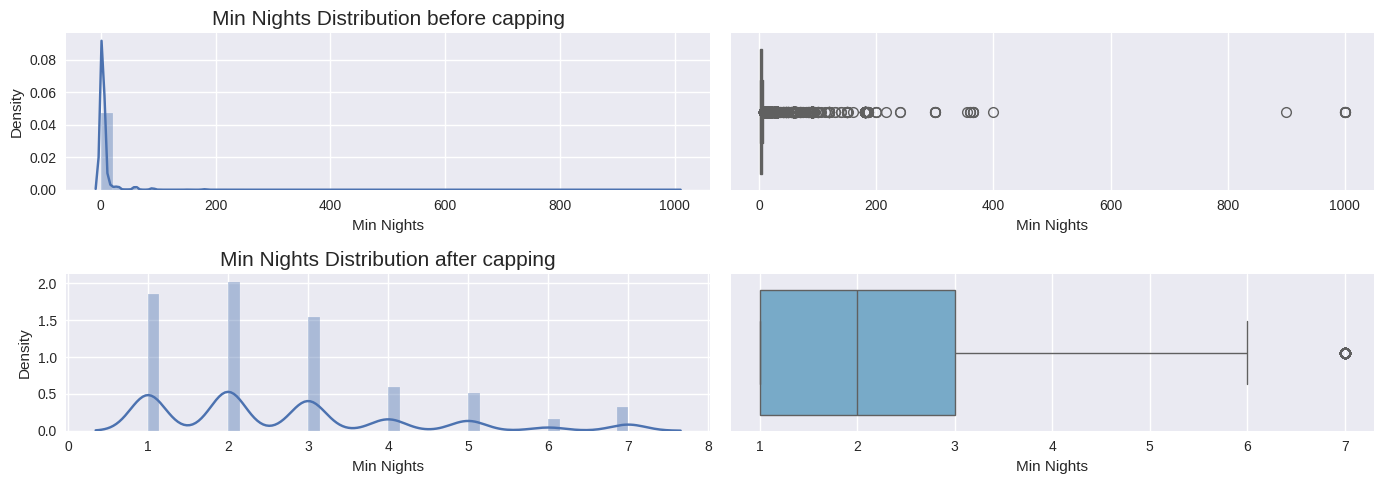

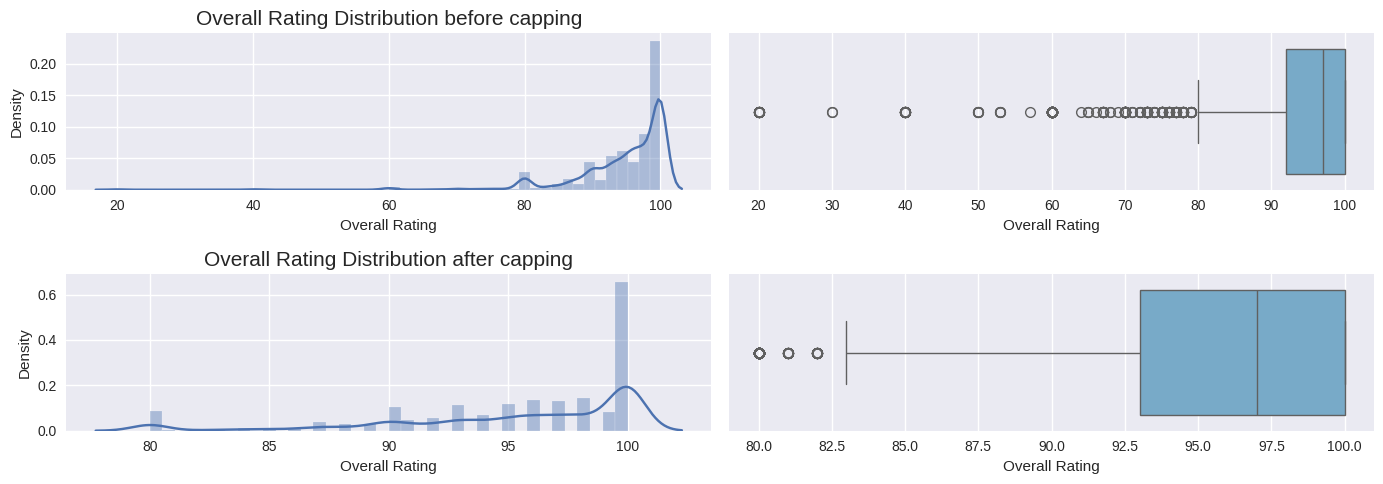

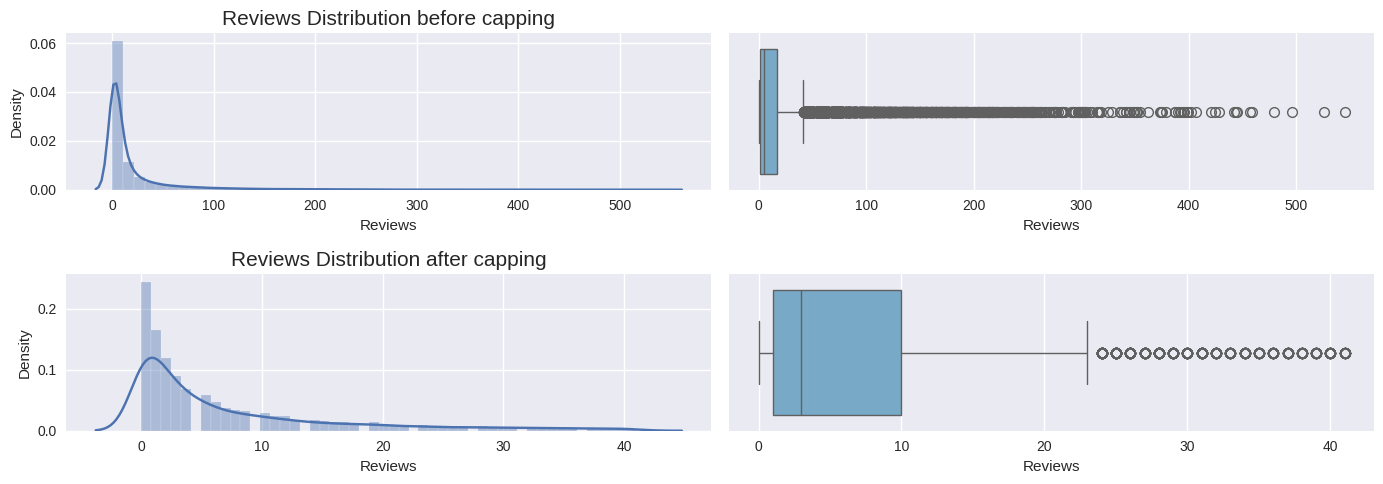

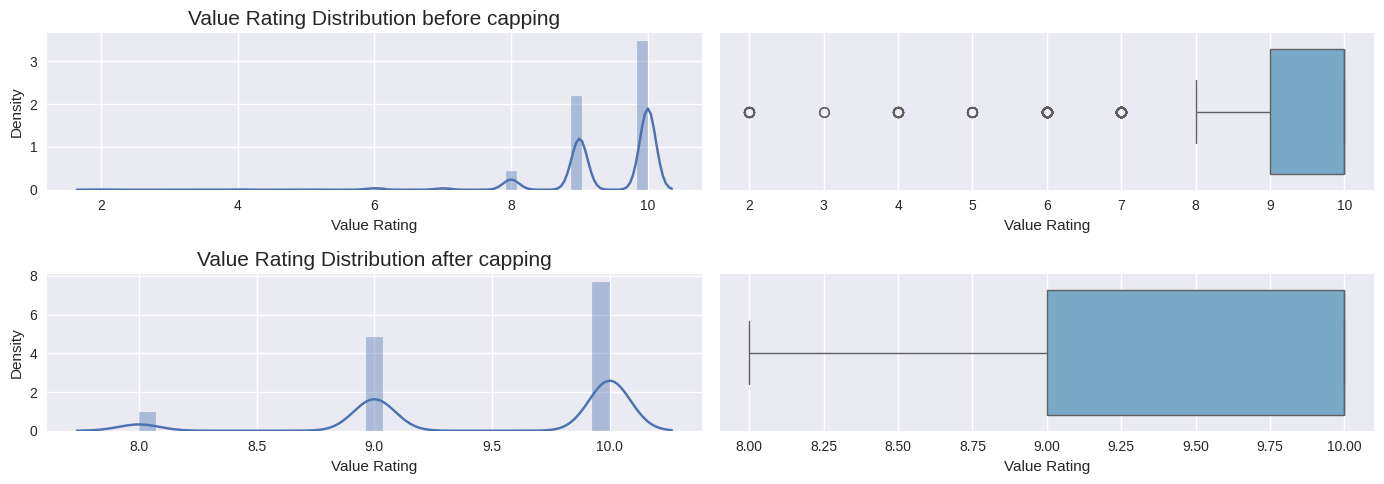

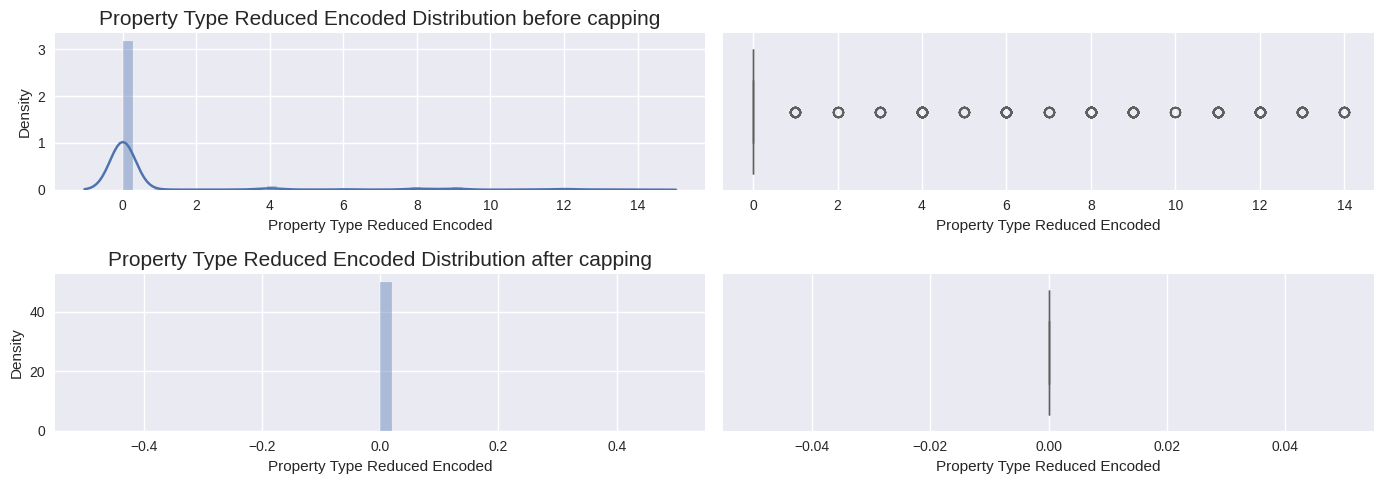

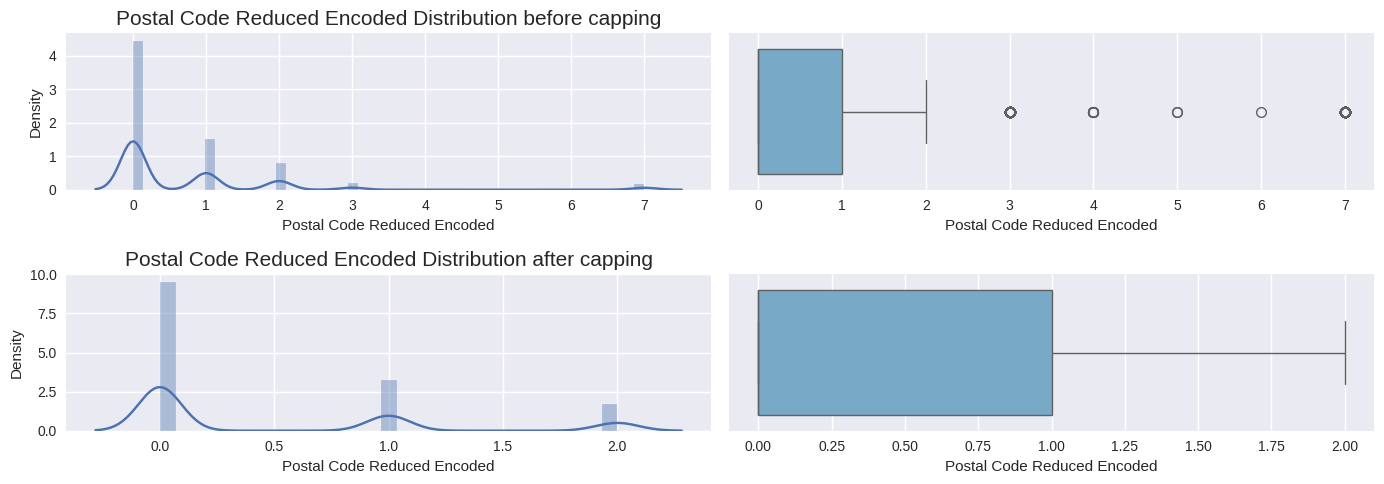

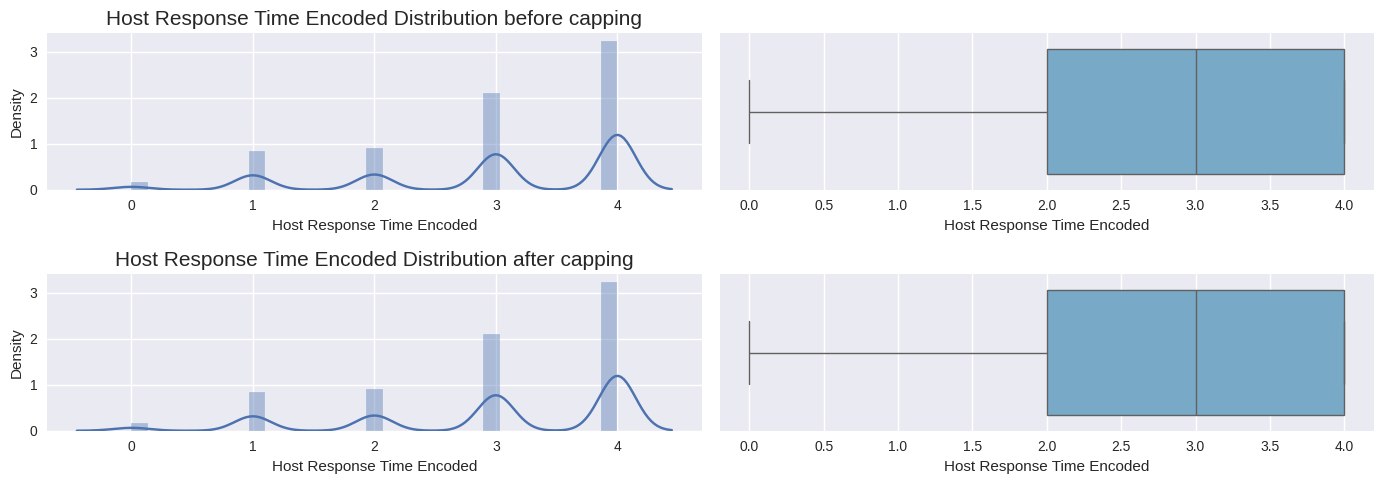

In [135]:
def dist_outliers(original_df, new, cols):
  for col in df_num_non_dummy:
      if col in cols:
        plt.figure(figsize=(14,5))

        plt.subplot(2,2,1)
        sns.distplot(original_df[col].dropna())
        plt.title('{} Distribution before capping'.format(col), fontsize=15)

        plt.subplot(2,2,2)
        sns.boxplot(x=original_df[col].dropna(), palette='Blues')
        plt.subplots_adjust(hspace = 0.6)

        plt.subplot(2,2,3)
        sns.distplot(new[col].dropna())
        plt.title('{} Distribution after capping'.format(col), fontsize=15)

        plt.subplot(2,2,4)
        sns.boxplot(x=new[col].dropna(), palette='Blues')
        plt.subplots_adjust(hspace = 0.6)

        plt.tight_layout()
        plt.show()

dist_outliers(df, temp, outliers_df.index)

We clearly need to filter some features that either the feature distribution has changed significantly, or cases where removing outliers results with only one value.

Checking if distribution (Kolmogorov–Smirnov) and/or correlation has changed significantly:

In [136]:
corr_mattrix = df[['Price', 'Reviews']].corr(method='spearman')
corr_mattrix.Price.loc['Reviews']

0.09328090599200146

In [137]:
df['Price'].corr(df['Reviews'], method='spearman')

0.09328090599200146

In [138]:
### differences between two correlation in Python: https://github.com/psinger/CorrelationStats
### We will only take from the code the Fisher method for two-tailed test
### Z-test to Compare Two Correlations???
def cocor(x1,y1, x2,y2):
    xy1 = x1.corr(y1, method='spearman')
    xy2 = x2.corr(y2, method='spearman')
    n1 = len(x1)
    n2 = len(x2)
    xy_z = 0.5 * np.log((1 + xy1)/(1 - xy1))
    ab_z = 0.5 * np.log((1 + xy2)/(1 - xy2))
    if n2 is None:
        n2 = n1
    se_diff_r = np.sqrt(1/(n1 - 3) + 1/(n2 - 3))
    diff = xy_z - ab_z
    z_score = abs(diff / se_diff_r)
    p_value = (1 - norm.cdf(z_score)) * 2
    return z_score, p_value

In [139]:
c=df_num_non_dummy.drop(columns=['Price'])
names=c.columns
#Creating df that reflects the correlation change
out_df= pd.DataFrame(columns=['feature','outliers_cnt','distribution_changed','correlation_changed'])

#A copy of numeric df
no_outliers=df_num_non_dummy.copy()
np.seterr(divide='ignore', invalid='ignore')
for i in names:
#     df with outliers
    out=df[i]
#     df with out outliers
    non=df[i].loc[new_df_outliers[i]==0]
#     lable with outliers
    price_out=df['Price']
#     lable with out outliers
    price_non=df['Price'].loc[new_df_outliers[i]==0]
#     cocor pvalue
    p, pvalue = cocor(out,price_out, non,price_non)
    cor_change=np.where(pvalue<0.05,'+','-')
#     outliers count
    mv=df_outliers.sum()
#    ks pvalue
    pval=ks_2samp(out, non)[1]
    dist_change=np.where(pval<0.05,'+','-')
    out_df = pd.concat([out_df, pd.DataFrame([{'feature':i,'outliers_cnt':mv,'distribution_changed':dist_change,'correlation_changed': cor_change}])], ignore_index=True)
out_df.head(20)

,feature,outliers_cnt,distribution_changed,correlation_changed
0,Listing ID,Listing ID 0 Accomoda...,-,-
1,Accomodates,Listing ID 0 Accomoda...,-,-
2,Accuracy Rating,Listing ID 0 Accomoda...,-,-
3,Bathrooms,Listing ID 0 Accomoda...,-,-
4,Bedrooms,Listing ID 0 Accomoda...,-,-
5,Beds,Listing ID 0 Accomoda...,-,-
6,Checkin Rating,Listing ID 0 Accomoda...,-,-
7,Cleanliness Rating,Listing ID 0 Accomoda...,-,-
8,Communication Rating,Listing ID 0 Accomoda...,-,-
9,Guests Included,Listing ID 0 Accomoda...,-,-


In [140]:
#All 'Yes' Vars in the 'Drop'colums shall be deleted, since the infect correlation and distribution.
#We don't want to delete vars that will change the distribution
out_df['drop']='yes'
out_df.loc[(out_df.distribution_changed=='+')& (out_df.correlation_changed=='+'),'drop'] = 'no'
out_df

,feature,outliers_cnt,distribution_changed,correlation_changed,drop
0,Listing ID,Listing ID 0 Accomoda...,-,-,yes
1,Accomodates,Listing ID 0 Accomoda...,-,-,yes
2,Accuracy Rating,Listing ID 0 Accomoda...,-,-,yes
3,Bathrooms,Listing ID 0 Accomoda...,-,-,yes
4,Bedrooms,Listing ID 0 Accomoda...,-,-,yes
5,Beds,Listing ID 0 Accomoda...,-,-,yes
6,Checkin Rating,Listing ID 0 Accomoda...,-,-,yes
7,Cleanliness Rating,Listing ID 0 Accomoda...,-,-,yes
8,Communication Rating,Listing ID 0 Accomoda...,-,-,yes
9,Guests Included,Listing ID 0 Accomoda...,-,-,yes


In [141]:
out_df.groupby('drop').size()

,0
drop,
yes,23


There are 19 features in total where removal of the outliers does not affect neither correlation nor distribution. And 23 features that shall be removed.

In [142]:
out_df.loc[out_df['drop']=='no']

,feature,outliers_cnt,distribution_changed,correlation_changed,drop


In [143]:
relevant_columns_features=out_df.loc[out_df['drop']=='yes']['feature']
relevant_columns_features

,feature
0,Listing ID
1,Accomodates
2,Accuracy Rating
3,Bathrooms
4,Bedrooms
5,Beds
6,Checkin Rating
7,Cleanliness Rating
8,Communication Rating
9,Guests Included


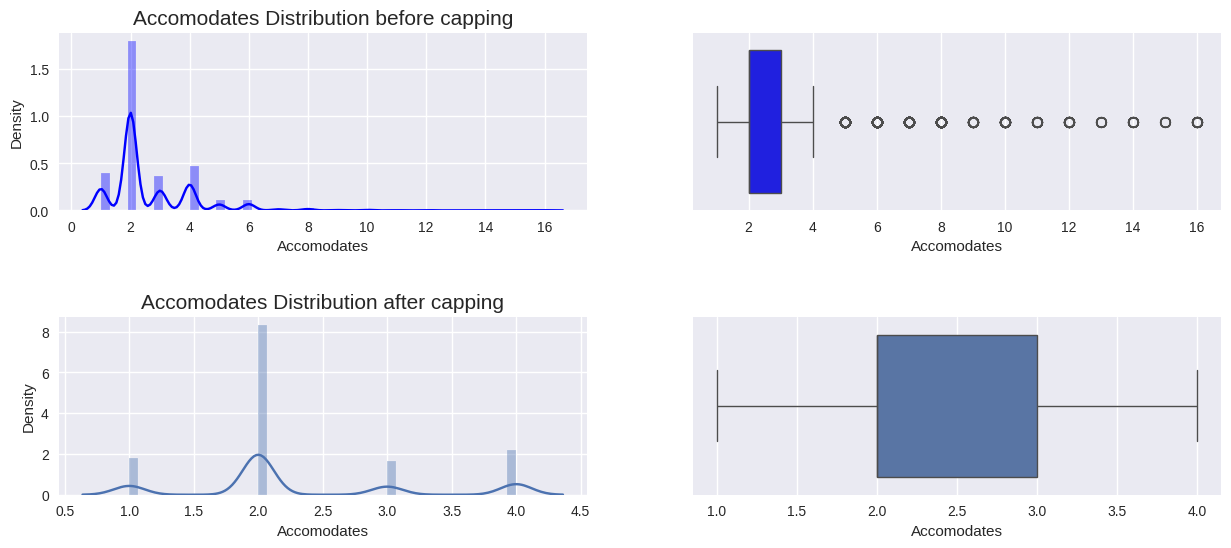

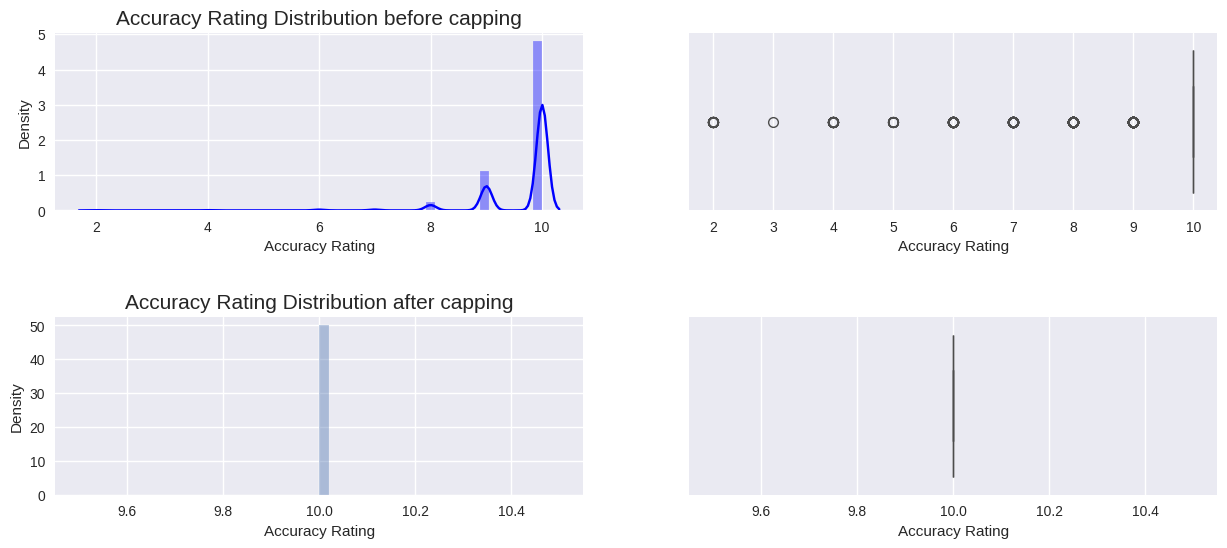

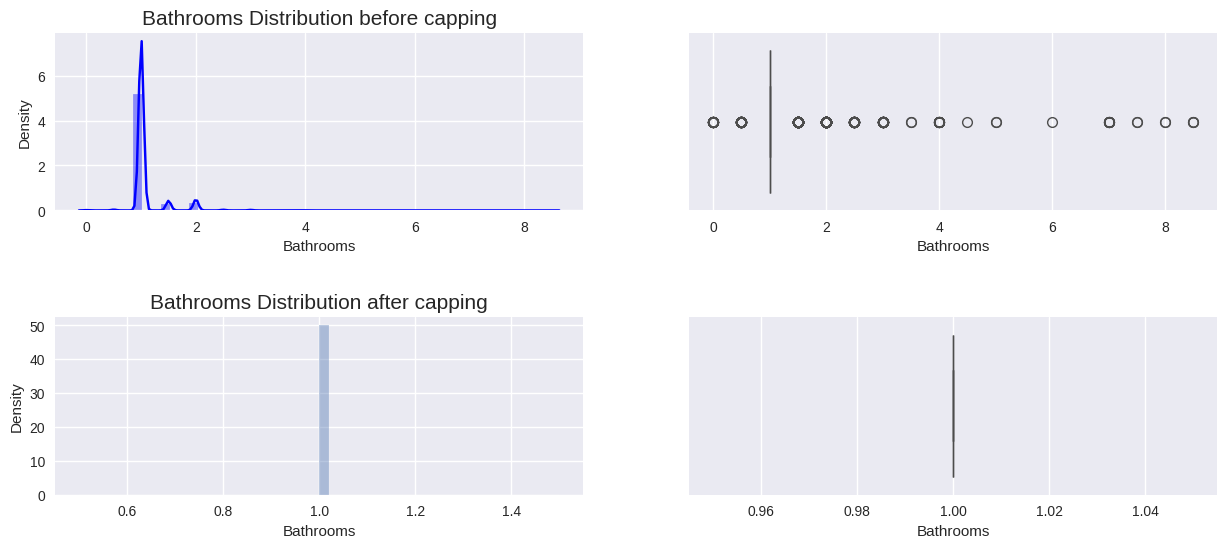

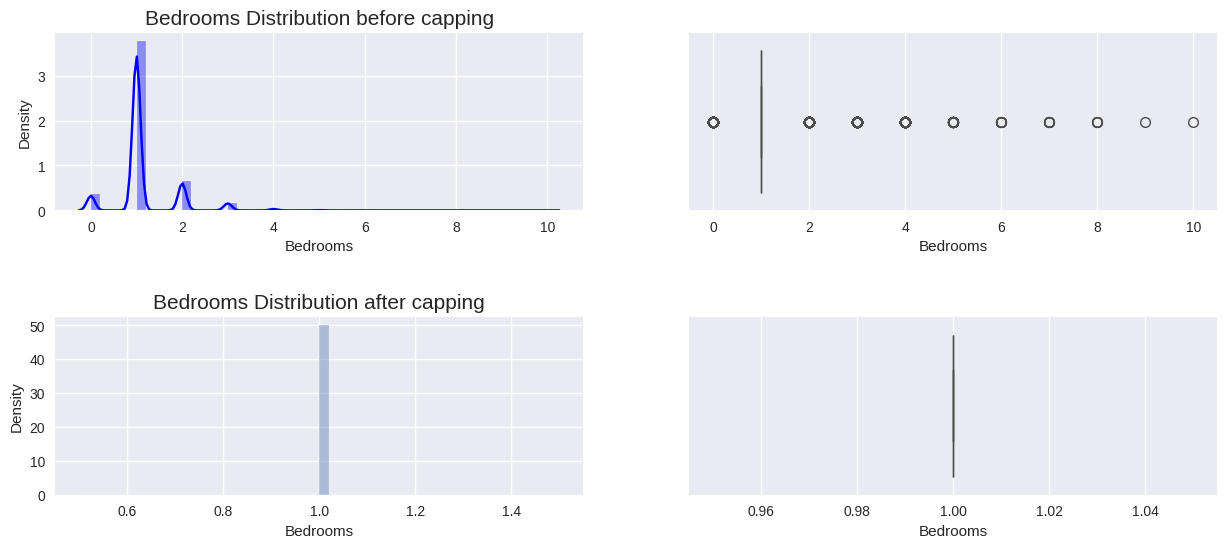

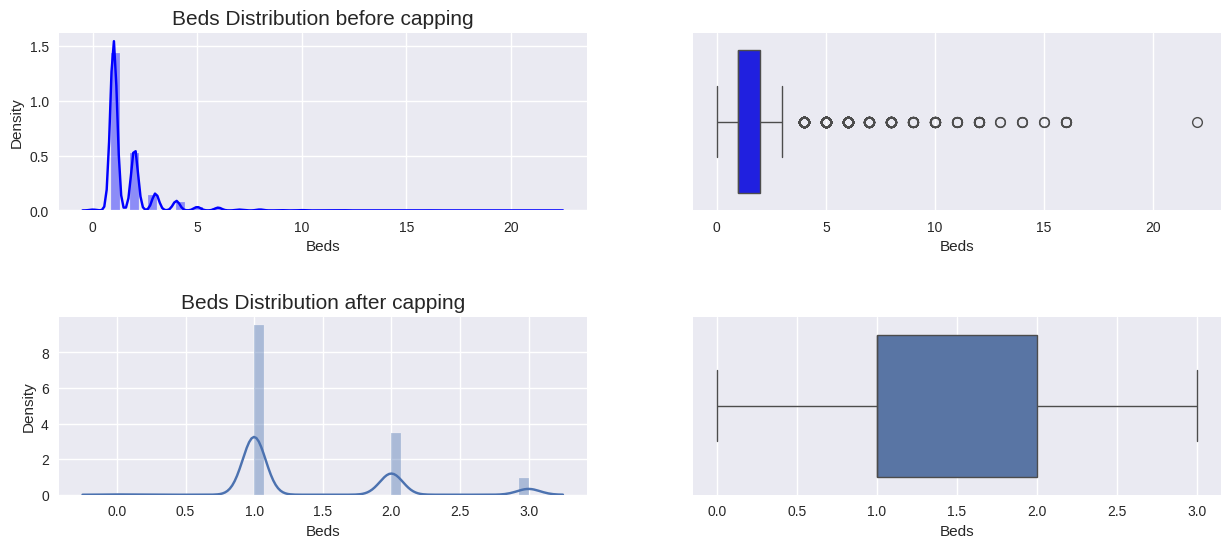

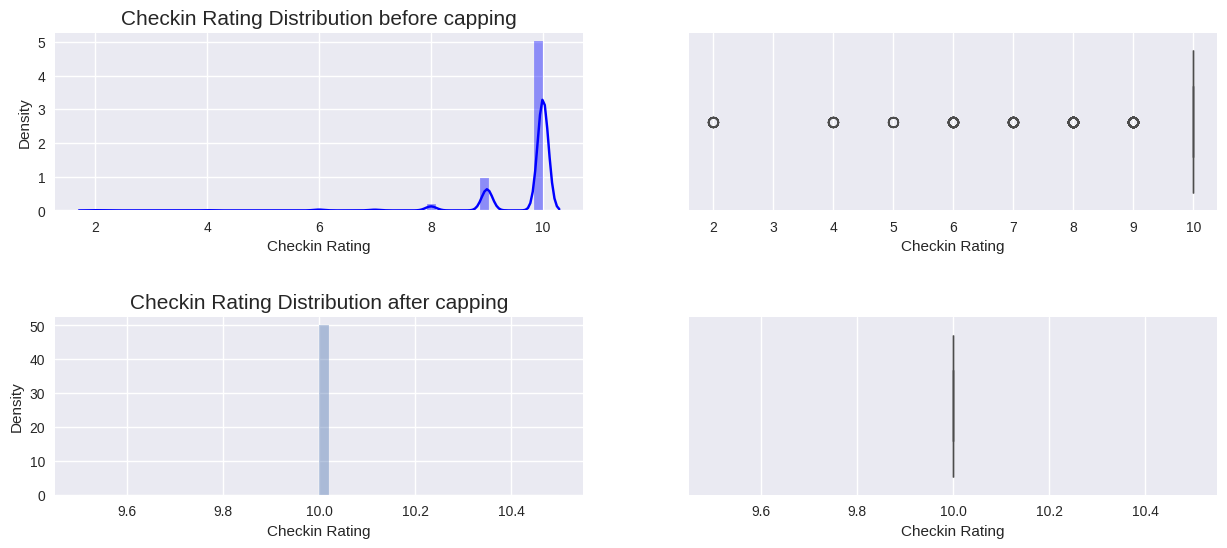

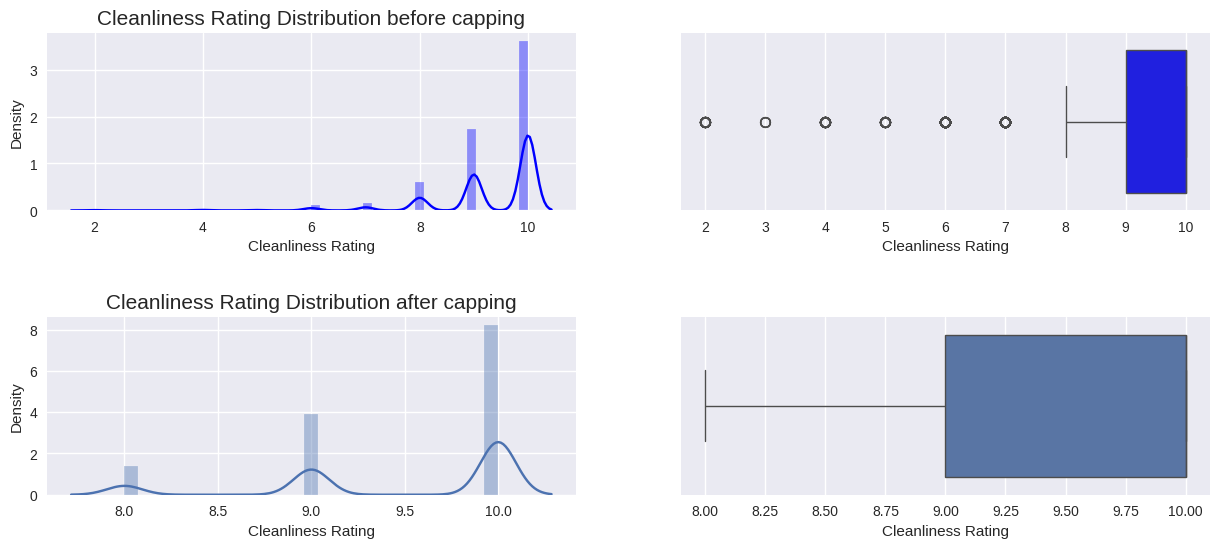

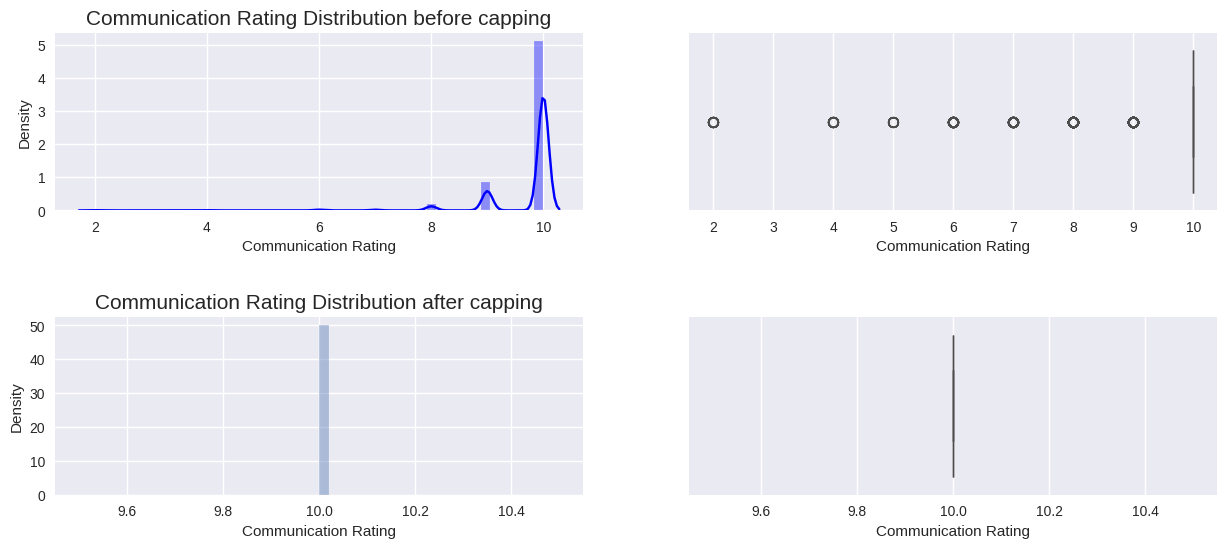

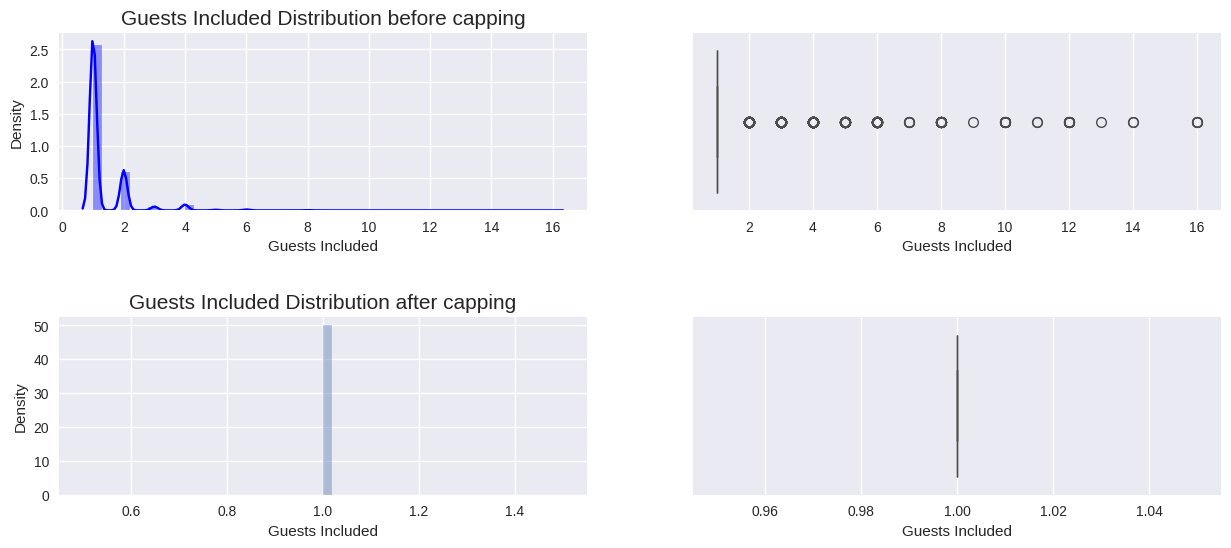

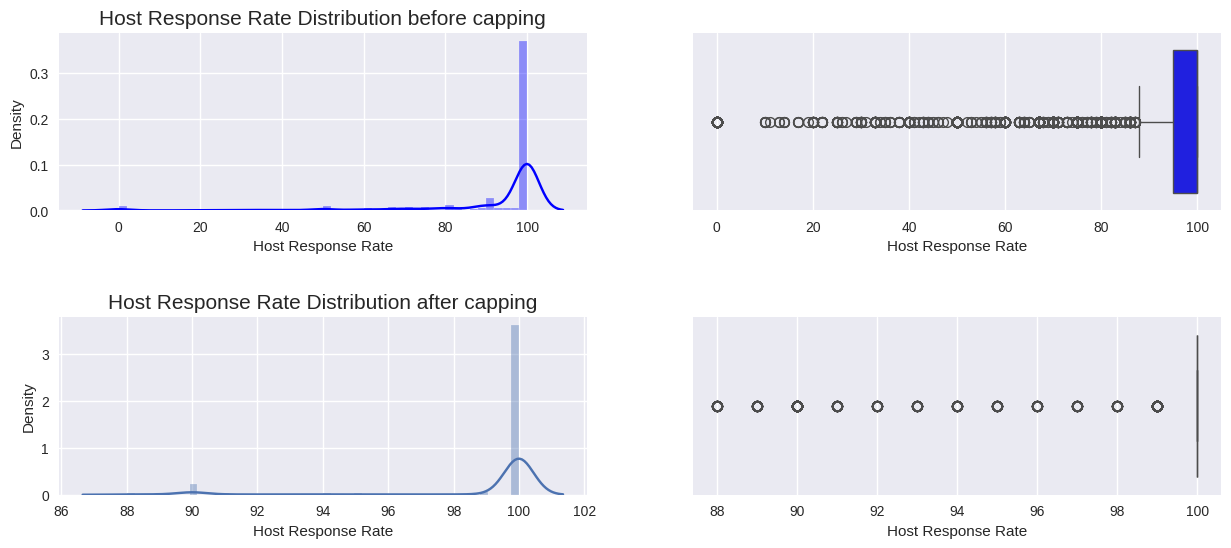

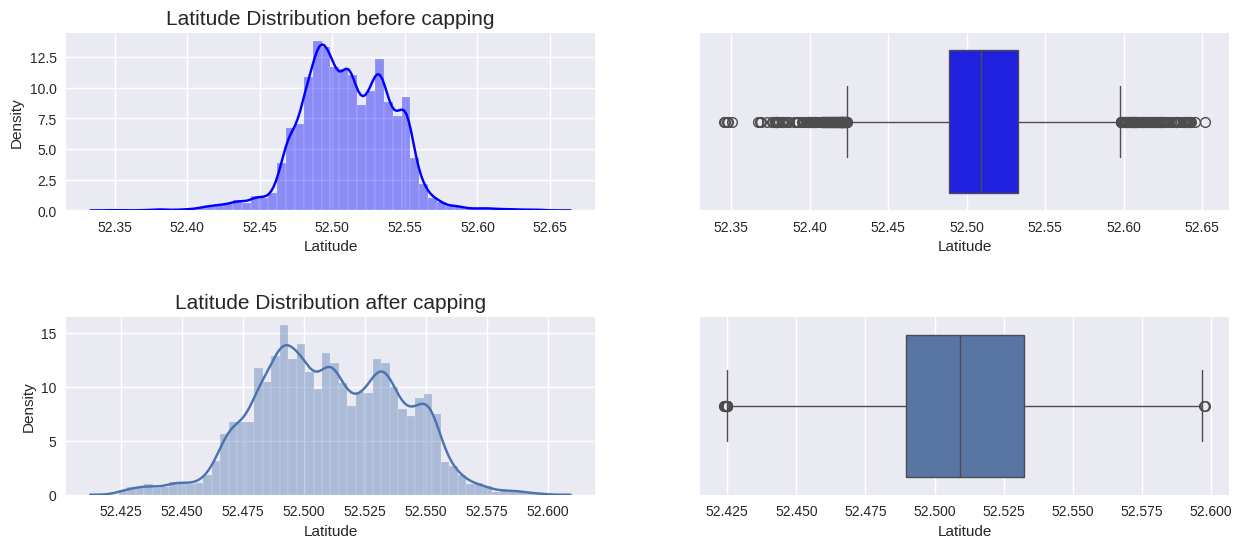

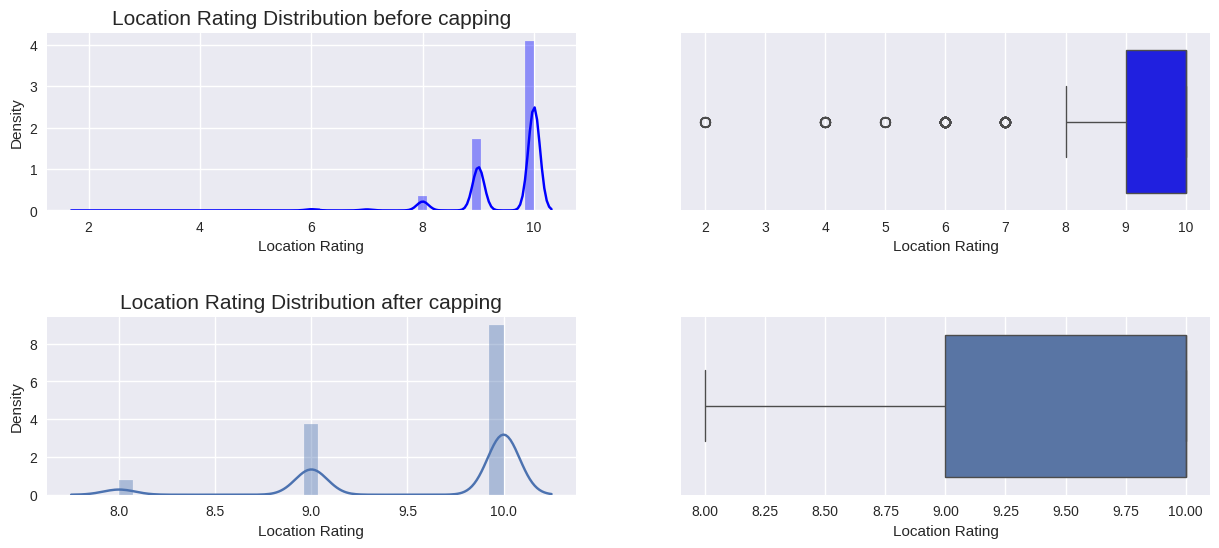

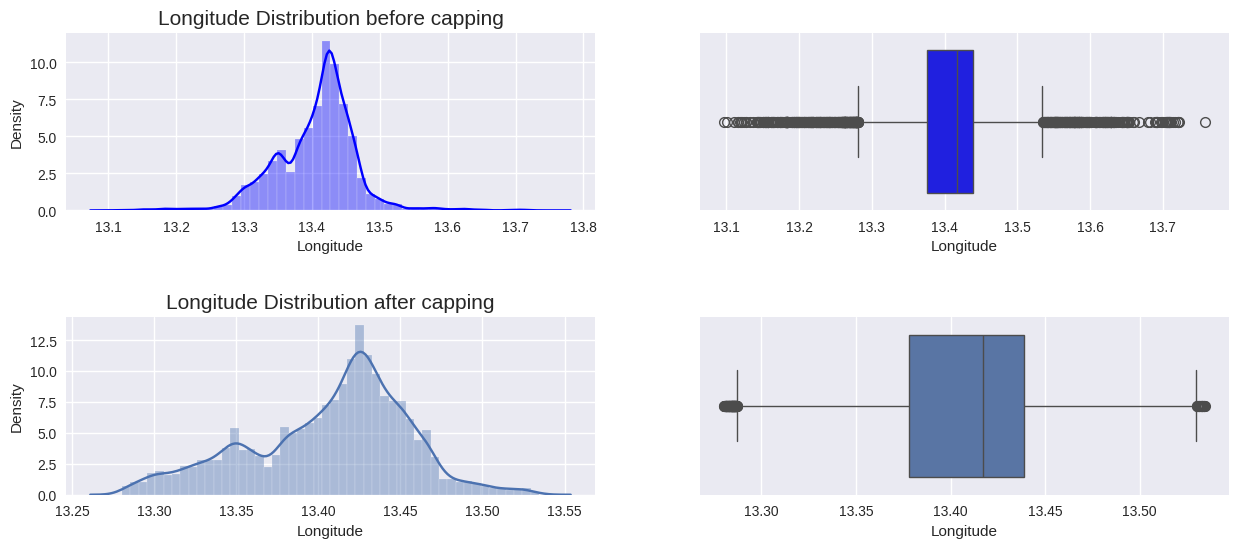

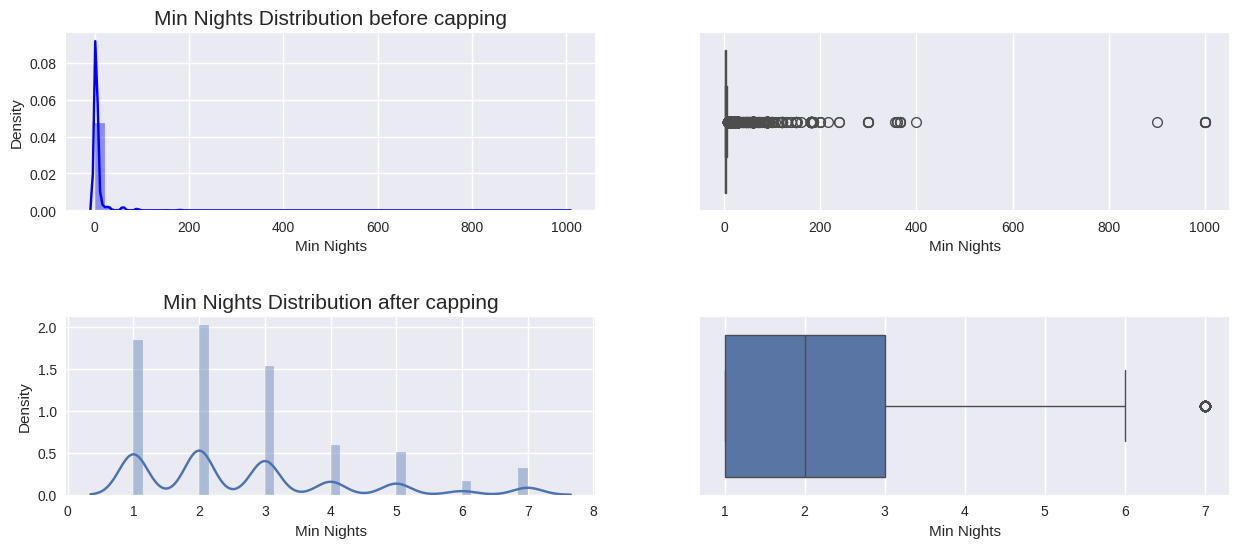

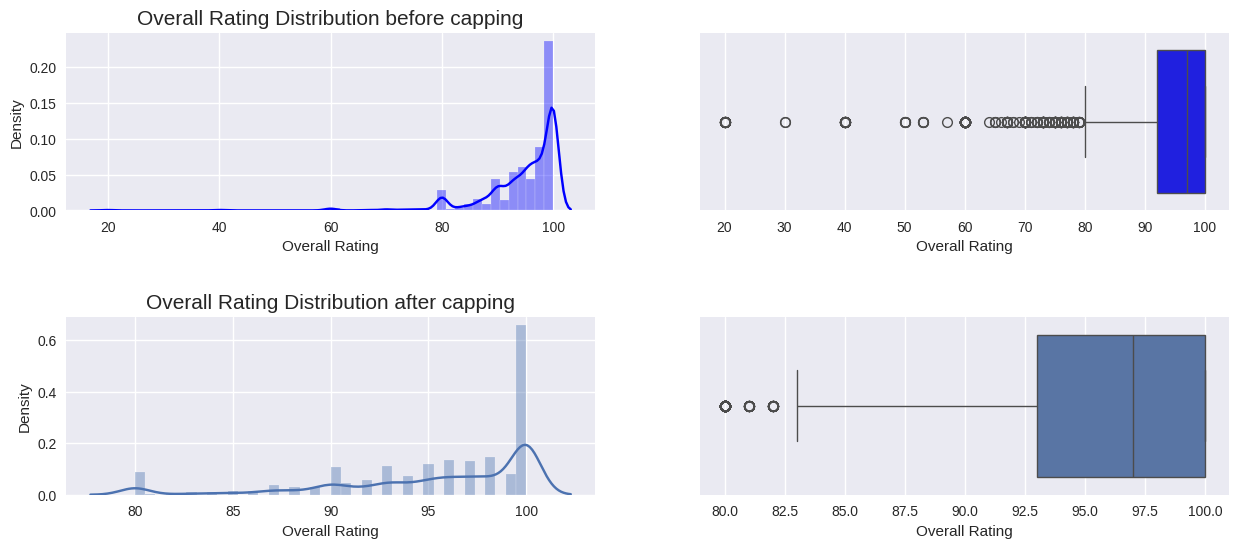

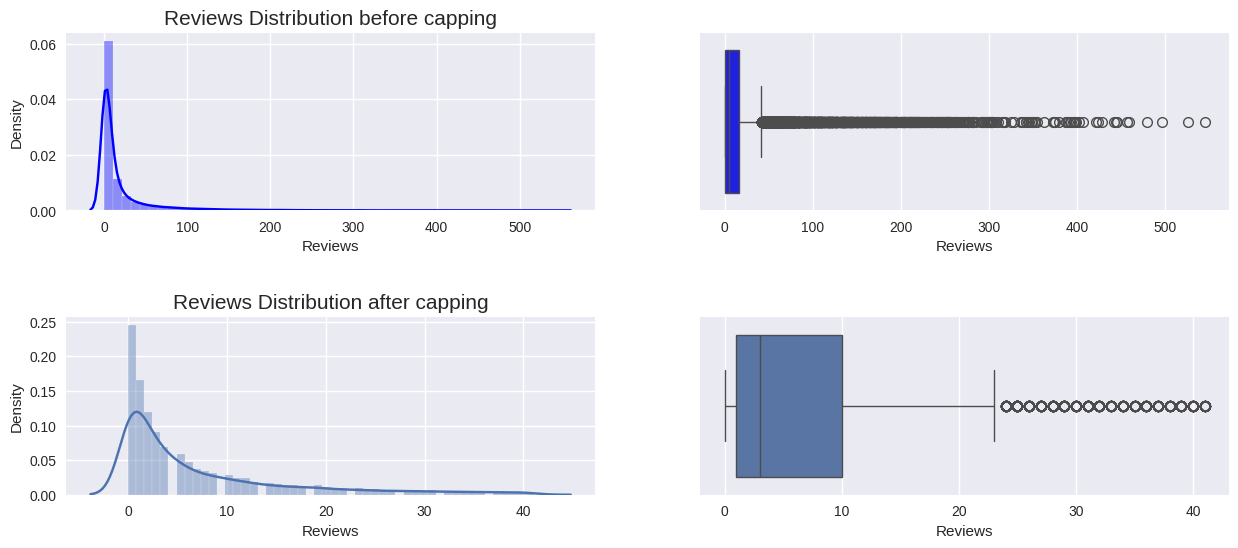

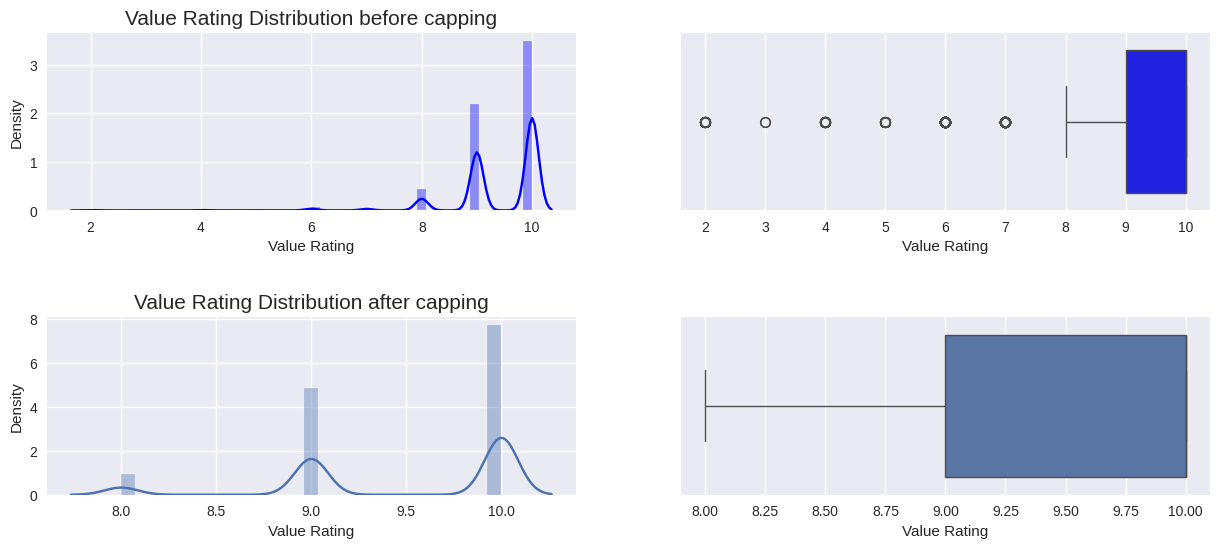

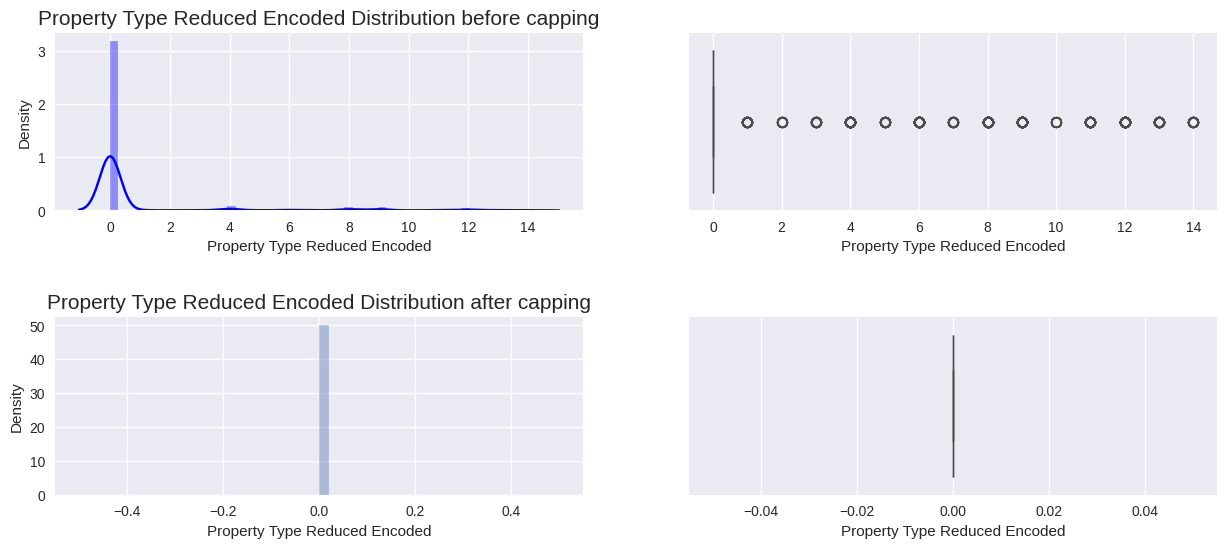

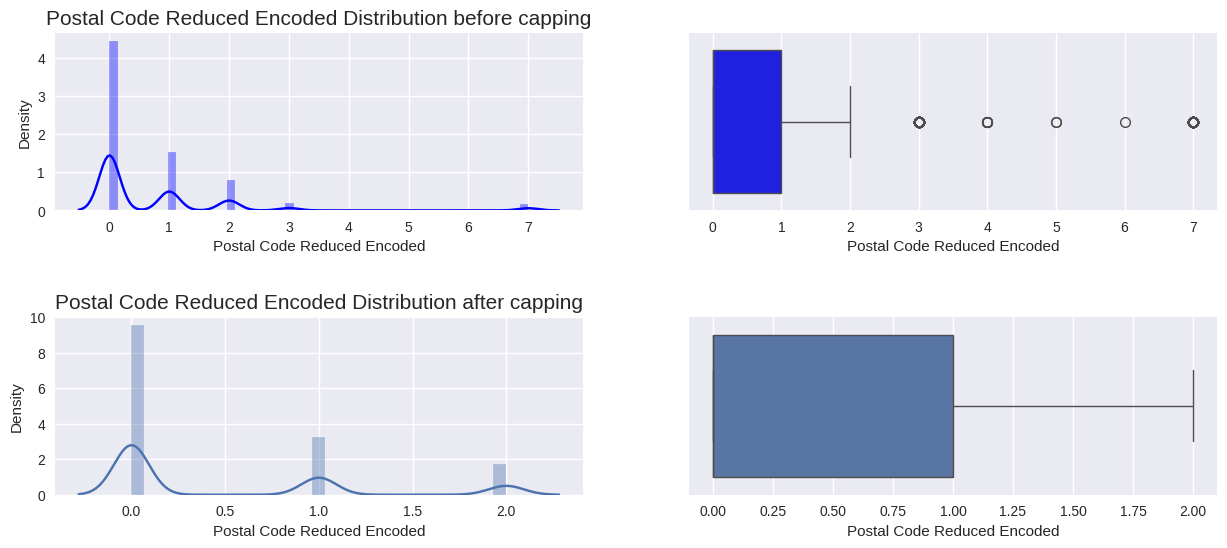

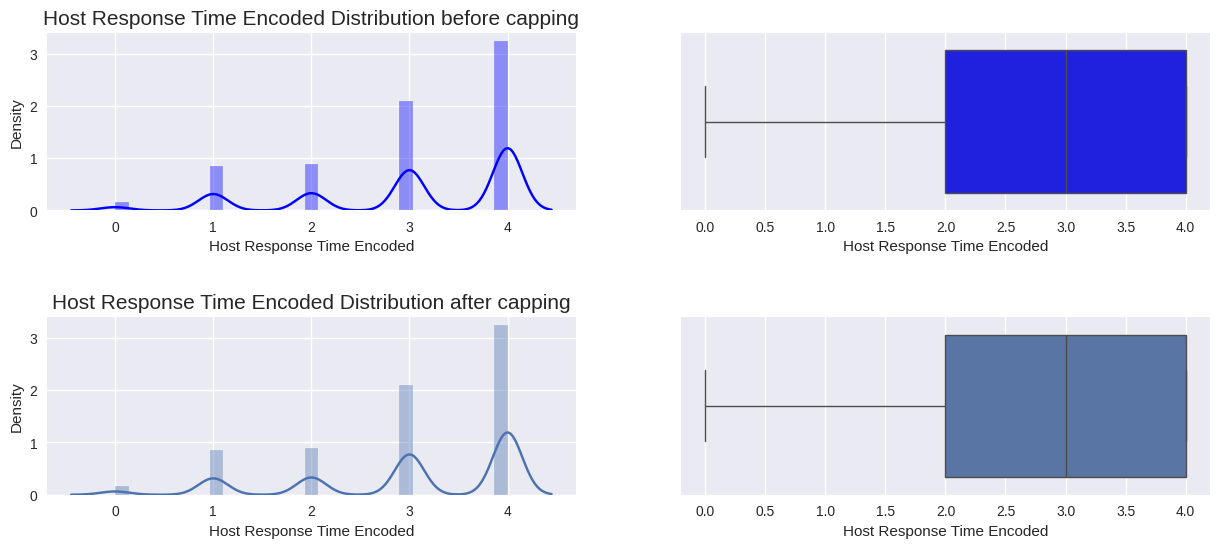

In [144]:
plt.style.use('seaborn-v0_8')
def dist_compare_after_capping(original_df, new, cols):
    for col in relevant_columns_features:
        if col in cols:
            plt.figure(figsize=(15,6))
            plt.subplot(2,2,1)
            sns.distplot(original_df[col], color='blue')
            plt.title('{} Distribution before capping'.format(col), fontsize=15)
            plt.subplot(2,2,2)
            sns.boxplot(x = original_df[col], color='blue')
            plt.subplots_adjust(hspace = 0.6)
            plt.subplot(2,2,3)
            sns.distplot(new[col])
            plt.title('{} Distribution after capping'.format(col), fontsize=15)
            plt.subplot(2,2,4)
            sns.boxplot(x = new[col])
            plt.show()
dist_compare_after_capping(df, temp, outliers_df.index)

In [145]:
relevant_columns_features.values

array(['Listing ID', 'Accomodates', 'Accuracy Rating', 'Bathrooms',
       'Bedrooms', 'Beds', 'Checkin Rating', 'Cleanliness Rating',
       'Communication Rating', 'Guests Included', 'Host Response Rate',
       'Latitude', 'Location Rating', 'Longitude', 'Min Nights',
       'Overall Rating', 'Reviews', 'Value Rating', 'Room Type Encoded',
       'Property Type Reduced Encoded', 'Neighborhood Group Encoded',
       'Postal Code Reduced Encoded', 'Host Response Time Encoded'],
      dtype=object)

Will only select the following columns to remove

In [146]:
remove_outliers=['Bathrooms', 'Accomodates', 'Min Nights', 'Host Response Rate']
remove_outliers

['Bathrooms', 'Accomodates', 'Min Nights', 'Host Response Rate']

Removing outleirs that don't change correlation

In [147]:
manipulated_data= df.copy()
for index, row in df_outliers.iterrows():  # Iterate through df_outliers with index
    for col in remove_outliers:
        if row[col] == 1:
            manipulated_data.loc[index,col] = 0  # Use the index from df_outliers

In [148]:
manipulated_data

,Listing ID,Accomodates,Accuracy Rating,Bathrooms,Bedrooms,Beds,Checkin Rating,Cleanliness Rating,Communication Rating,Guests Included,Host Response Rate,Latitude,Location Rating,Longitude,Min Nights,Overall Rating,Price,Reviews,Value Rating,review_date,Host Since,Host Response Time,Is Superhost,neighbourhood,Neighborhood Group,Postal Code,Is Exact Location,Property Type,Room Type,Instant Bookable,Neighbourhood Grouped,Property Type Reduced,Postal Code Reduced,Room Type Encoded,Property Type Reduced Encoded,Neighborhood Group Encoded,Postal Code Reduced Encoded,Host Response Time Encoded
0,2695,2.0,10.0,1.0,1.0,1.0,10.0,10.0,10.0,1.0,0.0,52.54851,9.0,13.40455,2.0,100.0,17.0,7.0,10.0,07-04-18,09-16-08,within a day,False,Prenzlauer Berg,Pankow,10437,True,Apartment,Private room,False,Pankow,Apartment,10,1,0,6,0,1
1,3176,4.0,9.0,1.0,1.0,2.0,9.0,9.0,9.0,2.0,0.0,52.53500,10.0,13.41758,0.0,92.0,90.0,144.0,9.0,06-20-09,10-19-08,within a day,False,Prenzlauer Berg,Pankow,10405,True,Apartment,Entire home/apt,False,Pankow,Apartment,10,0,0,6,0,1
2,7071,2.0,10.0,1.0,1.0,2.0,10.0,10.0,10.0,1.0,100.0,52.54316,10.0,13.41509,2.0,96.0,33.0,229.0,10.0,08-18-09,05-16-09,within an hour,True,Prenzlauer Berg,Pankow,10437,True,Apartment,Private room,False,Pankow,Apartment,10,1,0,6,0,3
3,9991,0.0,10.0,0.0,4.0,7.0,10.0,10.0,10.0,5.0,100.0,52.53303,10.0,13.41605,6.0,100.0,180.0,6.0,10.0,08-09-15,08-25-09,within a day,False,Prenzlauer Berg,Pankow,10405,False,Apartment,Entire home/apt,False,Pankow,Apartment,10,0,0,6,0,1
4,14325,1.0,10.0,1.0,0.0,1.0,9.0,10.0,10.0,1.0,100.0,52.54785,9.0,13.40556,0.0,93.0,70.0,23.0,9.0,06-29-10,11-18-09,within a day,False,Prenzlauer Berg,Pankow,10437,True,Apartment,Entire home/apt,False,Pankow,Apartment,10,0,0,6,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23531,34678365,3.0,NaN,1.0,1.0,2.0,NaN,NaN,NaN,1.0,0.0,52.42278,NaN,13.16120,0.0,NaN,48.0,0.0,NaN,None,10-23-18,within a few hours,False,Wannsee,Steglitz - Zehlendorf,14109,False,Apartment,Entire home/apt,True,Steglitz - Zehlendorf,Apartment,14,0,0,9,3,2
23532,34681094,2.0,NaN,1.0,2.0,2.0,NaN,NaN,NaN,2.0,NaN,52.63020,NaN,13.49340,5.0,NaN,30.0,0.0,NaN,None,05-13-19,None,False,Mitte,Pankow,13125,True,Apartment,Private room,True,Mitte,Apartment,13,1,0,6,2,4
23533,34681403,1.0,NaN,0.0,1.0,1.0,NaN,NaN,NaN,1.0,NaN,52.45402,NaN,13.43864,2.0,NaN,17.0,0.0,NaN,None,07-31-14,None,False,Britz,NeukÃ¶lln,12347,True,Apartment,Private room,True,NeukÃ¶lln,Apartment,12,1,0,5,1,4
23534,34681413,0.0,NaN,1.0,3.0,4.0,NaN,NaN,NaN,1.0,NaN,52.47342,NaN,13.58483,2.0,NaN,52.0,0.0,NaN,None,05-13-19,None,False,KÃ¶penick,Treptow - KÃ¶penick,12555,True,Apartment,Entire home/apt,True,Treptow - KÃ¶penick,Apartment,12,0,0,11,1,4


In [149]:
manipulated_data.to_csv('/content/drive/My Drive/Airbnb/manipulated_data_no_outleirs.csv')

## missing value

In [150]:
df_nulls = manipulated_data.copy()
for col in df_nulls:
    if df_nulls[col].isna().sum() == 0:
        del df_nulls[col]
df_nulls

,Accuracy Rating,Bathrooms,Bedrooms,Beds,Checkin Rating,Cleanliness Rating,Communication Rating,Host Response Rate,Location Rating,Overall Rating,Value Rating,review_date,Host Since,Host Response Time
0,10.0,1.0,1.0,1.0,10.0,10.0,10.0,0.0,9.0,100.0,10.0,07-04-18,09-16-08,within a day
1,9.0,1.0,1.0,2.0,9.0,9.0,9.0,0.0,10.0,92.0,9.0,06-20-09,10-19-08,within a day
2,10.0,1.0,1.0,2.0,10.0,10.0,10.0,100.0,10.0,96.0,10.0,08-18-09,05-16-09,within an hour
3,10.0,0.0,4.0,7.0,10.0,10.0,10.0,100.0,10.0,100.0,10.0,08-09-15,08-25-09,within a day
4,10.0,1.0,0.0,1.0,9.0,10.0,10.0,100.0,9.0,93.0,9.0,06-29-10,11-18-09,within a day
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23531,NaN,1.0,1.0,2.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,None,10-23-18,within a few hours
23532,NaN,1.0,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,05-13-19,None
23533,NaN,0.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,07-31-14,None
23534,NaN,1.0,3.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,05-13-19,None


<Axes: >

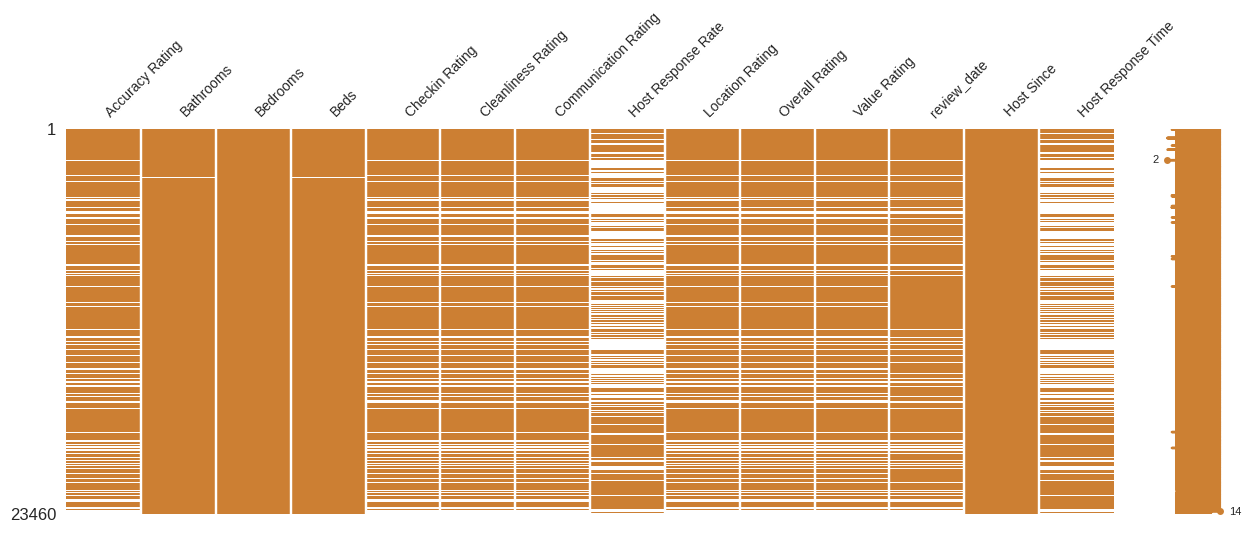

In [151]:
msno.matrix(df_nulls, figsize=(15, 5), fontsize=10, color=(0.8, 0.5, 0.2))

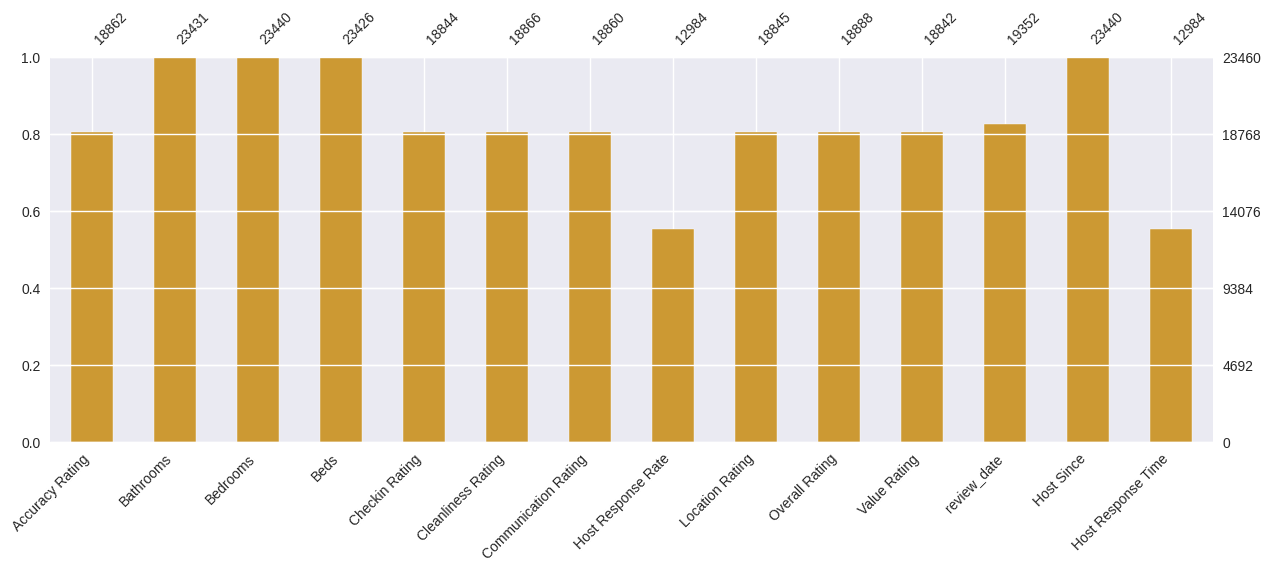

In [152]:
msno.bar(df_nulls, figsize=(15, 5), fontsize=10, color=(0.8, 0.6, 0.2));

In [153]:
mis_val = df_nulls.isna().sum()
mis_val_per = df_nulls.isna().sum()/len(df_nulls)*100
mis_val_table = pd.concat([mis_val, mis_val_per], axis=1)
mis_val_table_ren_columns = mis_val_table.rename(columns = {0 : 'Missing Values', 1 : '% of Total Values'})
mis_val_table_ren_columns = mis_val_table_ren_columns[mis_val_table_ren_columns.iloc[:,:] != 0].sort_values(
    '% of Total Values', ascending=False).round(1)
mis_val_table_ren_columns

,Missing Values,% of Total Values
Host Response Rate,10476,44.7
Host Response Time,10476,44.7
Value Rating,4618,19.7
Checkin Rating,4616,19.7
Location Rating,4615,19.7
Communication Rating,4600,19.6
Accuracy Rating,4598,19.6
Cleanliness Rating,4594,19.6
Overall Rating,4572,19.5
review_date,4108,17.5


Creating a dataframe with missing values as 1 and existing values as 0:

In [154]:
df_missing_data = manipulated_data.isin([np.nan])
df_missing_data = df_missing_data.astype('int')
df_missing_data

,Listing ID,Accomodates,Accuracy Rating,Bathrooms,Bedrooms,Beds,Checkin Rating,Cleanliness Rating,Communication Rating,Guests Included,Host Response Rate,Latitude,Location Rating,Longitude,Min Nights,Overall Rating,Price,Reviews,Value Rating,review_date,Host Since,Host Response Time,Is Superhost,neighbourhood,Neighborhood Group,Postal Code,Is Exact Location,Property Type,Room Type,Instant Bookable,Neighbourhood Grouped,Property Type Reduced,Postal Code Reduced,Room Type Encoded,Property Type Reduced Encoded,Neighborhood Group Encoded,Postal Code Reduced Encoded,Host Response Time Encoded
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23531,0,0,1,0,0,0,1,1,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
23532,0,0,1,0,0,0,1,1,1,0,1,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
23533,0,0,1,0,0,0,1,1,1,0,1,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
23534,0,0,1,0,0,0,1,1,1,0,1,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


Creating df including numeric features of the later data - manipulated_data

In [155]:
#Selecting numeric data
numeric_manipulated_data = manipulated_data.select_dtypes(include=[np.number])
numeric_manipulated_data.columns

Index(['Listing ID', 'Accomodates', 'Accuracy Rating', 'Bathrooms', 'Bedrooms',
       'Beds', 'Checkin Rating', 'Cleanliness Rating', 'Communication Rating',
       'Guests Included', 'Host Response Rate', 'Latitude', 'Location Rating',
       'Longitude', 'Min Nights', 'Overall Rating', 'Price', 'Reviews',
       'Value Rating', 'Room Type Encoded', 'Property Type Reduced Encoded',
       'Neighborhood Group Encoded', 'Postal Code Reduced Encoded',
       'Host Response Time Encoded'],
      dtype='object')

Difference in the distribution of a variable when another variable is with or without Missing Values:

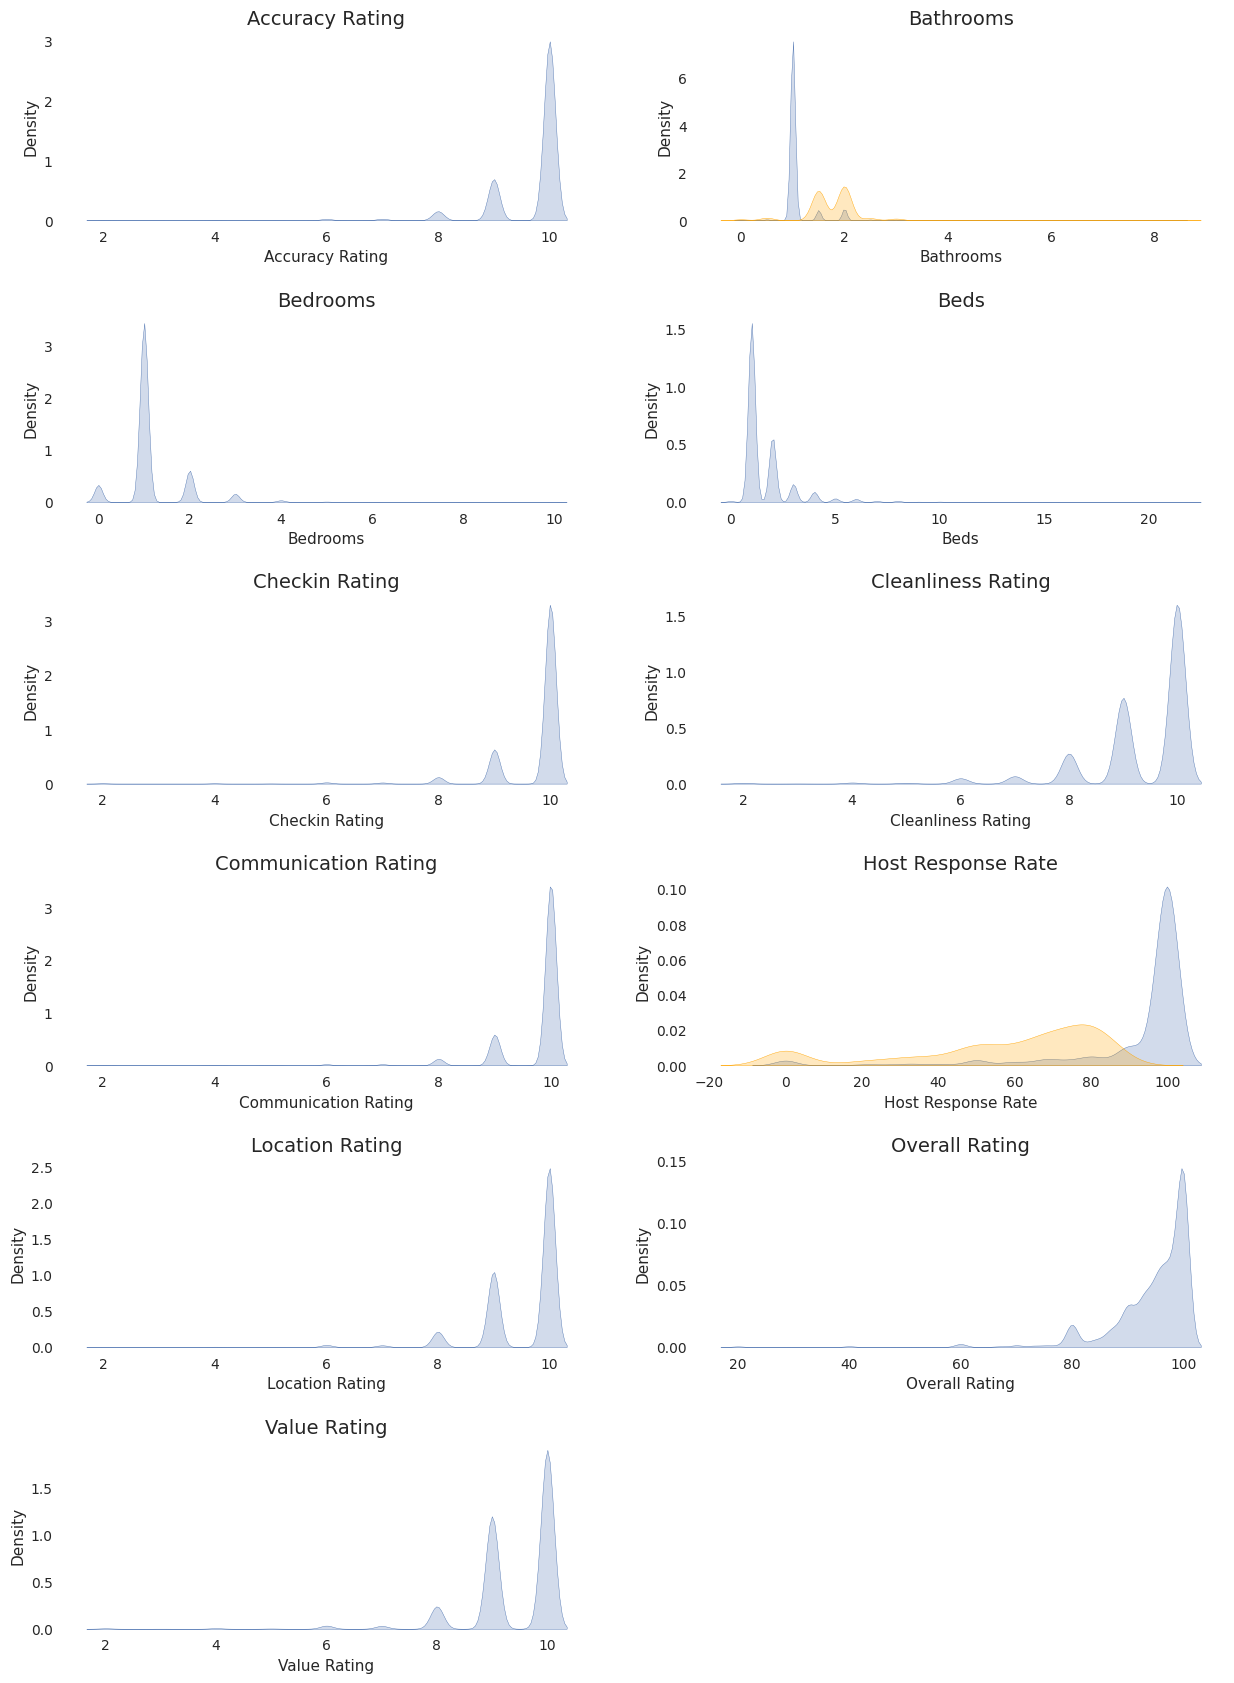

In [156]:
#c = numeric_manipulated_data.columns
colist = df_nulls.columns
#names = missing_names
#sns.set(font_scale = 0.8)
#sns.set_style("whitegrid")
sns.set_style("ticks")
sns.set
a=len(colist)
c=1
fig = plt.figure(figsize=(15,50))
plt.subplots_adjust(hspace=0.5)
for j in df_nulls.select_dtypes(include=[np.number]).columns:
        if j!=i :
            plt.subplot(a,2,c)
            plt.title('{}'.format(j),fontsize=14)
            plt.xlabel(j)
            sns.kdeplot(df[j],fill=True)
            sns.kdeplot(df[j].loc[df_nulls[j]==0],fill=True,color='orange')

        c=c+1

plt.show()

Exploring data the segnificunce of distribution change:

In [170]:
#le = preprocessing.LabelEncoder()
MV_df_final = pd.DataFrame(columns= ['Var', 'MV_pct', 'distribution_changed'])
#df[m] = le.fit_transform(df[m].astype(str))
m=numeric_manipulated_data.copy()
#m = manipulated_data._get_numeric_data().columns.dropna().unique()
np.seterr(divide='ignore', invalid='ignore')
for i in m:
    # and i in mis_val_table_ren_columns.index.tolist():
    # column with NULLS
        null = m[i]
    # column without NULLS
        non = m[i].loc[df_missing_data[i]==0]
    # target value with NULLS
        price_null = m['Price']
    # target value without NULLS
        price_non = price_null.loc[df_missing_data[i]==0]
        mv = df_missing_data[i].sum()
    # perform Kolmogorov-Smirnov test
        pval = ks_2samp(null, non)[1]
        dis_change = np.where(pval<0.5,'+','-')
        # MV_df_final = pd.concat([MV_df_final, pd.DataFrame({'Var': i, 'MV_pct': mv, 'distribution_changed': dis_change}, index=[0])], ignore_index=True)
        temp_df = pd.DataFrame({'Var': i, 'MV_pct': mv, 'distribution_changed': dis_change}, index=[0])
        # Concatenate the temporary DataFrame to the final DataFrame
        MV_df_final = pd.concat([MV_df_final, temp_df], ignore_index=True)
        MV_df_final = MV_df_final[MV_df_final['MV_pct'] > 0]
MV_df_final

,Var,MV_pct,distribution_changed
0,Accuracy Rating,4598,-
1,Bathrooms,29,-
2,Bedrooms,20,-
3,Beds,34,-
4,Checkin Rating,4616,-
5,Cleanliness Rating,4594,-
6,Communication Rating,4600,-
7,Host Response Rate,10476,-
8,Location Rating,4615,-
9,Overall Rating,4572,-


In [158]:
MV_df_final['drop']= 'Yes'
MV_df_final['MV_type']= 'MCAR/MAR'
MV_df_final.loc[(MV_df_final.distribution_changed== '+'),'drop']='No'
MV_df_final.loc[(MV_df_final.distribution_changed== '+'),'MV_type']='MNAR'
MV_df_final = MV_df_final[MV_df_final['MV_pct']>0].sort_values(by='MV_pct', ascending=False)
MV_df_final

,Var,MV_pct,distribution_changed,pval,drop,MV_type
10,Host Response Rate,10476,-,NaN,Yes,MCAR/MAR
18,Value Rating,4618,-,NaN,Yes,MCAR/MAR
6,Checkin Rating,4616,-,NaN,Yes,MCAR/MAR
12,Location Rating,4615,-,NaN,Yes,MCAR/MAR
8,Communication Rating,4600,-,NaN,Yes,MCAR/MAR
2,Accuracy Rating,4598,-,NaN,Yes,MCAR/MAR
7,Cleanliness Rating,4594,-,NaN,Yes,MCAR/MAR
15,Overall Rating,4572,-,NaN,Yes,MCAR/MAR
5,Beds,34,-,NaN,Yes,MCAR/MAR
3,Bathrooms,29,-,NaN,Yes,MCAR/MAR


# Data Imputation

# Next to Aggregation and Feature Engineering

In [159]:
df.to_pickle("/content/drive/My Drive/Airbnb/df_Feature_Engineering.pkl")

In [160]:
# df_Feature_Engineering = pd.read_pickle('/content/drive/My Drive/Airbnb/df_Feature_Engineering.pkl')
# df_Feature_Engineering.info()

# Candidate for Trash